> # This notebook is `tm_threshold_axis_sweep_largest_cc_high_z.ipynb` re-run at the 7.5 um NMS radius
>
> **What changed and why.** The original sets `NMS_RADIUS_UM = 5.0`. That value is not a
> considered choice made here: it propagated. `tm_threshold_axis_sweep_v2.ipynb` changed border
> padding **and** the NMS radius in one step and said in its own cost table that the two could
> not be separated; `..._largest_cc.ipynb` (*lcc*) inherited it, and the 5.0 um high_z run
> inherited it from lcc *deliberately*, so that its shared columns would reproduce lcc's CSV
> byte-for-byte.
>
> **F5 separated them.** `f5_nms_radius_ablation.py` (pre-registered, 5,040 arms, padding held
> ON in every arm, radius the only factor) found the padding was the part that helped and the
> radius shrink was not a benefit on either ranking axis, at a cost of 23-37% more candidates.
> Its section 7: *"The defensible configuration is padding ON, NMS radius back at the 7.5 um
> default -- which also restores `invariants.check_nms_radius` rather than overriding it."*
> `f6_padding_ablation.py:125` already runs at 7.5. This notebook did not.
>
> **The invariant.** `invariants.check_nms_radius` is invariant 4 of four: the suppression
> radius must equal the image's own evaluation match radius, because two detections closer than
> the match radius both survive suppression while both sit inside one ground-truth object,
> inflating the false-positive axis with duplicates. At 5.0 um that check cannot pass, and the
> 5.0 um notebook bypassed it by passing `nms_radius=None` at all four `compare.Arm` sites. It
> was never argued against -- it was routed around. **All four sites now pass the real radius,
> so invariant 4 runs as a positive control**, and its records are persisted to
> `results/tm_ccoeff_high_z_r75_verification.csv`.
>
> **What this costs.** This run is *not* byte-comparable to lcc -- it cannot be, and Check 1 is
> replaced accordingly with a paired r5.0-vs-r7.5 comparison that is a stronger test. Outputs
> are written to `*_r75*` paths; the 5.0 um CSVs are untracked and are left untouched so the
> comparison has something to read.
>
> ## What the run found -- read this before the inherited prose below
>
> The correction does **not** come out one-sided, and the notebook is not edited to pretend it
> does. Three results, all measured here, all in the closing section:
>
> 1. **The candidate-list cost of 5.0 um is real, and larger on this pool than F5's number.**
>    5.0 um carries a median **+55.6%** more candidates in the deep pool (18.9%-88.0%) and
>    **+43.5%** at the z = 1.0 operating point (11.3%-76.7%), against F5's +37.3% on its own
>    untightened 14-ROI pool. Correcting the radius is worth roughly a third of the list.
> 2. **7.5 um loses mitoses that 5.0 um found.** The deep pool reaches full recall in **31/35**
>    (domain, seed) cells at 7.5 um against **35/35** at 5.0 um -- **6 mitoses** missed outright.
> 3. **This notebook's deliverable does not survive the correction.** `z_max` is set by the
>    *worst-ranked* mitosis, so it is maximally sensitive to (2) and to a subtler effect: on 24
>    of 4,504 annotations found by both runs, the wider radius suppresses the strong peak on a
>    mitosis and the claim falls to a weaker surviving one (0 move the other way). One such
>    annotation on `548.tiff` drops from z = 4.199 to z = 0.438 and single-handedly sets the
>    global cutoff. The shippable global cutoff goes **1.308 -> 0.438**, which is *below* the
>    current operating point of 1.0, so it is worth a median **-10%** of the pool. **At 7.5 um
>    there is no z headroom to ship.**
>
> **This is not a refutation of F5.** F5 measured `full_list_recall` and `recall_at_budget` on
> its arms and never computed `z_max`; the quantity that collapses here is one F5 did not have.
> What F5 said about candidate volume is confirmed and strengthened. What is new is that the
> same knob also sets whether this notebook's headline exists at all.
>
> Everything below this banner is the original notebook, edited only where 5.0 um is named or
> where a gate cannot hold at 7.5 um. Each such edit says so in place.

---

# How high can the `z` cutoff go before a mitosis is lost?

**Purpose.** `tm_threshold_axis_sweep_largest_cc.ipynb` (below: *lcc*) runs the click-seeded
`TM_CCOEFF` search with largest-CC size-tightening and reports every metric at
`CURRENT_Z = 1.0`. Its own recall grid shows `full_list_recall == 1.0` at every `z <= 1.5`
in all seven domains, and never below 1.0 anywhere in the grid for `201.tiff`, `094.tiff`
and `402.tiff` -- so the operating point is nowhere near the constraint. This notebook
re-runs the identical sweep and asks the question lcc's grid can only bracket: **for each
domain, what is the exact highest cutoff that still keeps every mitotic figure the search
finds at all, and what does moving there actually buy?**

**The answer needs no grid search.** lcc already computes it and throws it away (cell 38's
`tp_z_min`, used only as the `frac_fp_in_tp_range` cut point and never printed). The
argument, in four steps:

1. `pool` is **already score-descending** when it is built. `template_match.extract_peaks`
   returns a globally lexsorted list (`np.lexsort((ys, xs, -scores))`), `nms.nms_by_distance`
   preserves that ordering (`np.argsort(-scores, kind="stable")` over an already-ordered
   array, and it returns the keeps best-first), and the `self_hit_radius` boolean mask
   preserves row order. Asserted directly in the main loop below, not assumed.
2. Each `tm_score` arm's candidate frame is `pool[pool['score'] >= cut]`, re-sorted stably by
   score in `compare._rank`. Given (1) that frame is **exactly a prefix** of the deep pool.
3. `evaluate.greedy_match` walks detections in rank order and claims each ground-truth point
   once. Matching a prefix is therefore literally the first *N* steps of matching the whole
   list -- no re-assignment, by construction (`evaluate.py`'s module docstring makes this the
   reason greedy matching was chosen: *"with one greedy pass every threshold is a truncation
   of the ranked list, so the curve is monotone by construction"*).
4. So `full_list_recall` at cutoff `z` is exactly
   `#{TP-bucketed detections in the deep pool with z >= cut} / n_gt_mitotic`.

Therefore **`z_max` = the lowest `z` among the deep pool's TP-bucketed detections**, exactly,
and inclusively (the cut is `score >= cut`, so the binding detection survives *at* `z_max`).
It is computed here in raw score units (`tp_score_min`) so no float round-trip through
`med + z*mad` can drop the binding candidate, with `z_max` reported alongside for reading.
Step 4 also requires the deep pool to reach full recall in the first place; that is measured
per domain, not assumed.

**What is held fixed.** Everything. Channel (`hematoxylin_od`), method (`TM_CCOEFF`), the
largest-CC tightening rule and its gates, the seed-draw rule and `SEED_INDEX = 0`, the two
border fix (padding so the whole ROI is reachable), **`NMS_RADIUS_UM = 7.5` -- the one
change, see the banner**,
`OD_PAD = 25` for the chromatin window, `DEEP_FLOOR_Z = -1.5`, `peak_min_distance = 7`,
`self_hit_radius = 5.0`, `Z_LEVELS`, and `CURRENT_Z = 1.0` as the *reference* operating point.
The only additions are three new arms per domain (at `z_max`, and a one-notch-higher control)
and the diagnostics below. **The NMS radius has moved**, so the shared columns are no longer
comparable to `results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv`; they are compared
instead against the 5.0 um high_z run, which differs by that one argument and nothing else.

## Read this before reading any number below

* **Raising `z` does not reduce what a pathologist reads.** On the `tm_score` axis,
  `recall_at_budget` is *exactly* invariant across the whole z sweep wherever
  `n_detections >= budget` (a score-descending list's top-K cannot change when only
  lower-scoring entries are deleted), and `compare._read_depths` is a `searchsorted` into a
  prefix of the *same* `tp_cum` array, so every `read_*` is either identical or `NaN`. Both
  are demonstrated below rather than argued. What a higher cutoff buys is full-list
  precision, downstream compute over the candidate set, the `chromatin_od` arm's top-K
  (the one place z moves recall@K at all), and a **much stronger recall claim** -- see the
  coverage point next.
* **`coverage_frac` is reported at every operating point -- but it cannot rehabilitate a
  recall number that has no freedom to move.** `evaluate.py` requires it before any full-list
  number: *"a detection list long enough to tile the ROI answers 'is this annotation within
  the match radius of some detection?' by geometry rather than by evidence."* That guard bites
  on a threshold chosen *before* looking at the labels. It does **not** apply to
  `full_list_recall == 1.0` at `z_max`: `z_max` is *defined* as the lowest TP score, so full
  recall there is true by construction, at coverage 0.06 for exactly the same reason it is
  true at coverage 0.99. The informative quantity is `z_max` **itself** -- how far above the
  map's median the worst-ranked mitosis sits -- not the recall measured at it. Where the guard
  does bite is the **deployable** cutoff, and it is reported there: `z ~ 1.31` leaves coverage
  at 0.79-0.99, squarely the regime `evaluate.py` calls geometry rather than evidence.
* **`z_max` is fitted to each ROI's own labels.** It is an upper bound on the available
  headroom, **not a deployable threshold** -- at inference you do not know where the mitoses
  are. The deployable question is "what fixed `z` is safe across ROIs, domains and clicks",
  and that is answered with a margin, over seeds, in the last two sections.
* **`chromatin_od` is reported, never used to decide.** `DECISIONS.md` D5's standing
  constraint requires the 14 ROIs of `images/extra_valid/` for any run that ranks by a
  chromatin statistic, *including as a compared axis*. This notebook uses the same 7-ROI
  draw lcc used (D5 was written after lcc ran), so every `chromatin_od` number here is
  **non-decision-grade** and is labelled as such where it appears. The recommendation is
  made on `tm_score` alone.
* **Two corrections carried in from `Research Logs/2026-09-04-largest-cc-z-headroom-audit.md`.**
  (i) lcc's closing summary claims every `read_95_delta` is smaller than its own ROI's
  seed-to-seed SD; joined on `file_name` that is false for `459.tiff` (+1416 vs SD 1199) and
  `402.tiff` (-1547 vs SD 593). The "not measurable at this sample size" verdict still rests
  on the three seed-0 endpoint hits, which are unaffected. (ii) `pool_sorted` is built here
  with `kind='mergesort'`, matching `compare._rank` and `extract_peaks`' documented tie
  convention; lcc used pandas' default unstable quicksort for that one frame.

In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

from midog_utils import chromatin as cm
from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
from sklearn.neighbors import KDTree

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration -- byte-identical to `tm_threshold_axis_sweep_largest_cc.ipynb`

Copied, not re-derived, so any difference in a shared column is a bug rather than a config
drift. `CURRENT_Z = 1.0` stays as the *reference* point every "vs. the current operating
point" comparison below is measured against; it is not what this notebook recommends.
`SEEDS` is the only genuinely new knob -- `compare.summarise`'s docstring
(*"Never report a single-seed number (Step 0 rule 5)"*) applies to a threshold more than to
anything else in this repo, since a threshold is a thing you ship.

In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0
SELF_HIT_RADIUS = 5.0

Z_LEVELS = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
CURRENT_Z = 1.0                          # lcc's operating point -- the reference, not the recommendation
DEEP_FLOOR_Z = min(Z_LEVELS) - 0.5
MAX_PEAKS = 2_000_000

# THE ONE FACTOR CHANGED IN THIS NOTEBOOK. The 5.0 um value the high_z/lcc/v2 line
# inherited is F5's `r5.0` arm; F5 section 7 recommends 7.5 um and this restores it.
# Equal to MATCH_RADIUS_UM, so `invariants.check_nms_radius` (invariant 4) is satisfied
# and is switched ON below as a positive control instead of being bypassed.
NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM       # 7.5
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

BUDGETS = cp.BUDGETS
AXES = ('tm_score', 'chromatin_od')
AXIS_RANK_KEY = {'tm_score': 'score', 'chromatin_od': 'od'}

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2   # 36
OTSU_WINDOW = tm.BASE_SIZE     # 51
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)
OD_PAD = tm.BASE_SIZE // 2     # 25 -- the chromatin window's own margin, independent of PAD

FP_SUBSAMPLE_CAP = 8000
RNG_SEED = 0

# NEW. The threshold is the deliverable, so it gets the 5-seed treatment f1_seed_sweep.py
# uses, with the identical draw rule: np.random.default_rng([seed_index, image_id]) over the
# full border-filtered agreement pool, with draw_seed_with_retry on largest_cc_box.
SEEDS = tuple(range(5))
# Candidate count as a function of the cutoff, recorded per (domain, seed) so that the volume
# saved by ANY proposed threshold -- including the worst-over-seeds one, which is not on
# Z_LEVELS -- is answerable from the saved CSVs without re-running the sweep.
Z_DENSE = tuple(np.round(np.arange(0.0, 6.001, 0.05), 2))

BUCKET_COLOR = {ev.HUMAN_CORRECT_LABEL: '#2ca02c',
                ev.HUMAN_REJECTED_LABEL: '#ff7f0e',
                ev.NON_HUMAN_FINDINGS: '#7f7f7f'}
BUCKET_LANE = {ev.HUMAN_CORRECT_LABEL: 2, ev.HUMAN_REJECTED_LABEL: 1, ev.NON_HUMAN_FINDINGS: 0}
STYLE = {
    ev.NON_HUMAN_FINDINGS: dict(s=5, alpha=0.10, zorder=1),
    ev.HUMAN_REJECTED_LABEL: dict(s=10, alpha=0.35, zorder=2),
    ev.HUMAN_CORRECT_LABEL: dict(s=22, alpha=0.9, zorder=3, edgecolors='#145214', linewidths=0.3),
}
print('config ok')

config ok


## `largest_cc_box` and `draw_seed_with_retry` -- copied verbatim from lcc

Unchanged, including the synthetic retry test, so this notebook's seed draw is provably the
same one. (Still local to the notebook rather than in `midog_utils/seed_selection.py`, for
lcc's reason: this rule was historically probed and explicitly *not* adopted as production
logic -- `Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, Experiment 5.)

In [3]:
def _odd_local(n: int, minimum: int = 5) -> int:
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''Otsu-threshold `patch` and return the bbox of its LARGEST connected component by area,
    regardless of whether it contains the click. (y0, y1, x0, x1), patch-local, half-open,
    or None. Mirrors seed_selection.tighten_box_otsu's "binary" path with only the
    component-selection step changed.'''
    if patch.ndim != 2:
        raise ValueError(f"largest_cc_box needs a single-channel patch, got shape {patch.shape}")
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    regions = regionprops(labels)
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area:
        return None
    if largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


def draw_seed_with_retry(pool: pd.DataFrame, rng, check_fn):
    '''Draw a row from `pool` via `rng.integers`; on failure, drop it and redraw, consuming
    the same rng stream. Returns (row, result, n_retries). Raises if the pool empties.'''
    working = pool.copy()
    retries = 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError("seed pool exhausted -- no candidate passed check_fn after all retries")


class _StubRNG:
    def integers(self, n):
        return 0


fake_pool = pd.DataFrame({'val': [10, 20, 30]}, index=[100, 101, 102])
row, result, retries = draw_seed_with_retry(
    fake_pool, _StubRNG(), lambda r: None if r['val'] == 10 else r['val'])
assert (row['val'], result, retries) == (20, 20, 1), 'retry path regressed'
try:
    draw_seed_with_retry(pd.DataFrame({'val': [1, 2]}), _StubRNG(), lambda r: None)
    raise AssertionError('expected ValueError on pool exhaustion')
except ValueError:
    pass
print('largest_cc_box / draw_seed_with_retry defined; both synthetic retry paths pass')

largest_cc_box / draw_seed_with_retry defined; both synthetic retry paths pass


## One ROI per domain -- the same seven

In [4]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)

_rows = []
for _, r in domain_images.iterrows():
    mpp = ds.roi_mpp(f"images/{r['file_name']}")
    _rows.append({'tumor_type': r['tumor_type'], 'file_name': r['file_name'],
                  'n_mitotic': r['n_mitotic'], 'mpp': round(mpp, 4),
                  'match_radius_px': round(ev.radius_px(mpp, MATCH_RADIUS_UM), 2),
                  'nms_radius_px': round(ev.radius_px(mpp, NMS_RADIUS_UM), 2)})
pd.DataFrame(_rows)

,tumor_type,file_name,n_mitotic,mpp,match_radius_px,nms_radius_px
0,canine cutaneous mast cell tumor,301.tiff,218,0.2533,29.61,29.61
1,canine lung cancer,201.tiff,18,0.2482,30.22,30.22
2,canine lymphosarcoma,246.tiff,116,0.2482,30.22,30.22
3,canine soft tissue sarcoma,459.tiff,131,0.2482,30.22,30.22
4,human breast cancer,094.tiff,82,0.2298,32.63,32.63
5,human melanoma,548.tiff,239,0.2274,32.98,32.98
6,human neuroendocrine tumor,402.tiff,105,0.2263,33.14,33.14


## Main sweep

One deep pool per domain per seed, built exactly as lcc's. For **seed 0** the full arm set is
evaluated: lcc's `Z_LEVELS` grid on both axes (the grid that pairs against the 5.0 um run),
plus three new arms --

* `tm_score@zmax` / `chromatin_od@zmax` -- cut at `score >= tp_score_min`, the exact highest
  cutoff that keeps every TP;
* `tm_score@zmax_strict` -- cut at `score > tp_score_min`, i.e. **one notch higher**, which
  must lose exactly the binding detection. This is the control that turns the closed-form
  argument into a measurement: recall must be 1.0 in the first and below 1.0 in the second.

For **seeds 1-4** only the deep pool and its `tp_score_min` are computed (no arms, no
coverage), because that is all the robustness section needs and it keeps the run under ~10
minutes. The ROI is loaded once per domain and reused across its five seeds.

In [5]:
all_rows, seed_rows, tpz_rows, checks_rows, vol_rows = [], [], [], [], []
# NEW at r7.5: `compare.evaluate_arms` only records an invariant when the caller hands
# it a list. The 5.0 um run could not run invariant 4 at all (it would have raised), so
# it passed `nms_radius=None` everywhere and never collected. Both are reversed here.
inv_checks = []
kept_pools, kept_gt, roi_meta = {}, {}, {}   # every seed's pool, so the deployable cutoffs
                                             # below can be EVALUATED rather than interpolated
pools = {}          # fn -> seed-0 bucketed detection frame (score-descending)
gt_by_file = {}     # fn -> seed-0 gt_eval, for the unanimity split below
import gc

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t_dom = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    roi_shape = rgb.shape
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]
    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, roi_shape)
    del rgb
    gc.collect()

    def _check(cand_row, _gray_inv=gray_inv):
        _patch = tm.read_padded_patch(_gray_inv, float(cand_row['cx']), float(cand_row['cy']),
                                      OTSU_WINDOW)
        return None if _patch is None else largest_cc_box(_patch, **LARGEST_CC_KW)

    for si in SEEDS:
        t0 = time.time()
        rng = np.random.default_rng([si, image_id])
        seed, seed_box, n_retries = draw_seed_with_retry(pool_seed, rng, _check)
        seed_xy = (float(seed['cx']), float(seed['cy']))
        seed_ann_id = int(seed['ann_id'])
        y0, y1, x0, x1 = seed_box
        base_size = _odd_local(max(y1 - y0, x1 - x0), minimum=5)
        gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)

        patch73 = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
        templates, _ = tm.build_augmentations(patch73, base_size, CFG.scales,
                                              CFG.n_angles, CFG.flips)
        PAD = max((t.shape[0] - 1) // 2 for t in templates)
        hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
        fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize,
                                                     method=METHOD)
        fused = fused_p[PAD:PAD + H, PAD:PAD + W]
        valid = valid_p[PAD:PAD + H, PAD:PAD + W]
        assert bool(valid.all()), f'{fn} s{si}: padding did not make the whole ROI valid'
        del hem_p, fused_p, best_p, valid_p
        gc.collect()

        med, mad = tm.robust_stats(fused, valid)
        deep_floor = med + DEEP_FLOOR_Z * mad
        centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)
        keep = nms_by_distance(centers, scores, nms_radius)
        centers, scores = centers[keep], scores[keep]
        ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
        centers, scores = centers[ok], scores[ok]

        pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
        pool['z'] = (pool['score'] - med) / mad

        # --- STEP 1 OF THE CLOSED FORM, ASSERTED: the pool is already score-descending, so a
        # score cut is a prefix and compare._rank cannot reorder it. Not assumed anywhere.
        already_sorted = bool(np.all(np.diff(pool['score'].to_numpy()) <= 0))
        assert already_sorted, f'{fn} s{si}: pool is not score-descending -- prefix argument void'

        od_naive_nan = int(cm.score_detections(pool[['cx', 'cy']].copy(), hem)['od'].isna().sum())
        hem_od_p = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD,
                                      borderType=cv2.BORDER_REPLICATE)
        shifted = pool[['cx', 'cy']].assign(cx=pool['cx'] + OD_PAD, cy=pool['cy'] + OD_PAD)
        pool['od'] = cm.score_detections(shifted, hem_od_p)['od'].to_numpy()
        assert int(pool['od'].isna().sum()) == 0, f'{fn} s{si}: od still NaN after the padding fix'
        del hem_od_p
        gc.collect()

        # --- bucket the deep pool. mergesort (lcc used pandas' default quicksort here), so the
        # tie order matches compare._rank exactly and this frame IS the arms' ranking.
        pool_sorted = pool.sort_values('score', ascending=False,
                                       kind='mergesort').reset_index(drop=True)
        assert pool_sorted['score'].equals(pool['score']), \
            f'{fn} s{si}: stable re-sort changed the order of an already-sorted pool'
        det_out, gt_out = ev.bucket_detections(pool_sorted, gt_eval, match_radius)

        n_mit = int((gt_eval['category_id'] == ds.MITOTIC).sum())
        tp = det_out[det_out['bucket'] == ev.HUMAN_CORRECT_LABEL]
        deep_recall = len(tp) / n_mit
        tp_z_sorted = np.sort(tp['z'].to_numpy())
        tp_score_sorted = np.sort(tp['score'].to_numpy())
        tp_score_min = float(tp_score_sorted[0])
        z_max = float(tp_z_sorted[0])
        if deep_recall < 1.0:
            print(f"[{fn} s{si}] NOTE: deep pool recall is {deep_recall:.4f}, not 1.0 -- z_max is "
                  f"'keeps every mitosis this pool finds', not 'every mitosis'", flush=True)

        n_at_current = int((pool['score'] >= med + CURRENT_Z * mad).sum())
        n_at_zmax = int((pool['score'] >= tp_score_min).sum())
        seed_rows.append({
            'tumor_type': domain, 'file_name': fn, 'seed_index': si, 'seed_ann_id': seed_ann_id,
            'n_retries': n_retries, 'base_size': base_size, 'n_pool': len(pool),
            'n_gt_mitotic': n_mit, 'deep_recall': round(deep_recall, 4),
            'map_median': med, 'mad_scale': mad,
            'z_max': z_max,            # full precision, NEVER rounded: this is a minimum, and
            'tp_score_min': tp_score_min,   # round-to-nearest moves it UP in ~half of all cells,
                                            # which then drops the binding mitosis when used as a cut

            'n_at_current_z': n_at_current, 'n_at_z_max': n_at_zmax,
            'pct_pool_cut': round(100 * (1 - n_at_zmax / n_at_current), 2)})

        kept_pools[(fn, si)] = pool[['cx', 'cy', 'score', 'z', 'od']].copy()
        kept_gt[(fn, si)] = gt_eval
        roi_meta[fn] = {'mpp': mpp, 'match_radius': match_radius, 'roi_shape': roi_shape,
                            'nms_radius': nms_radius}

        for zz in Z_DENSE:
            vol_rows.append({'file_name': fn, 'tumor_type': domain, 'seed_index': si,
                             'z': float(zz),
                             'n_at_z': int((pool['score'] >= med + zz * mad).sum())})

        # every TP's z, kept for the order-statistics and unanimity sections
        for rk, (_, r_tp) in enumerate(tp.sort_values('z').iterrows()):
            tpz_rows.append({'file_name': fn, 'tumor_type': domain, 'seed_index': si,
                             'tp_rank_from_bottom': rk, 'z': float(r_tp['z']),
                             'score': float(r_tp['score']),
                             'matched_ann_id': int(r_tp['matched_ann_id'])})

        if si == SEED_INDEX:
            pools[fn] = det_out
            gt_by_file[fn] = gt_eval

            # one-match-many-z shortcut, re-verified at the NEW operating point as well
            for tag, cut in (('current_z', med + CURRENT_Z * mad), ('z_max', tp_score_min)):
                c2, s2 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
                k2 = nms_by_distance(c2, s2, nms_radius)
                c2 = c2[k2]
                c2 = c2[np.hypot(c2[:, 0] - seed_xy[0], c2[:, 1] - seed_xy[1]) > CFG.self_hit_radius]
                filt = pool.loc[pool['score'] >= cut, ['cx', 'cy']].to_numpy()
                a = c2[np.lexsort((c2[:, 1], c2[:, 0]))] if len(c2) else c2
                b = filt[np.lexsort((filt[:, 1], filt[:, 0]))] if len(filt) else filt
                ok_sc = (a.shape == b.shape) and bool(np.allclose(a, b))
                assert ok_sc, f'{fn}: one-match-many-z shortcut failed at {tag}'
                checks_rows.append({'file_name': fn, 'domain': domain, 'check': f'shortcut@{tag}',
                                    'n_direct': len(c2), 'n_filtered': len(filt), 'passed': ok_sc})

            _dgt, _ = KDTree(gt_eval[['cx', 'cy']].to_numpy()).query(
                det_out[['cx', 'cy']].to_numpy(), k=1)
            checks_rows.append({'file_name': fn, 'domain': domain, 'check': 'dup_fp_deep_pool',
                                'n_direct': int(((_dgt[:, 0] <= match_radius) &
                                                 (det_out['bucket'] == ev.NON_HUMAN_FINDINGS)
                                                 .to_numpy()).sum()),
                                'n_filtered': len(det_out), 'passed': True})

            ctx = {'file_name': fn, 'image_id': image_id, 'tumor_type': domain,
                   'mpp': round(mpp, 4), 'seed_index': si, 'seed_ann_id': seed_ann_id,
                   'base_size': base_size, 'n_retries': n_retries,
                   'map_median': round(med, 5), 'mad_scale': round(mad, 5),
                   'deep_floor': round(deep_floor, 5), 'n_pool': len(pool),
                   'pad_px': PAD, 'nms_radius_px': round(nms_radius, 3),
                   'match_radius_px': round(match_radius, 3),
                   'z_max': z_max, 'deep_recall': round(deep_recall, 4)}

            arms = []
            for z in Z_LEVELS:
                cut = med + z * mad
                sub = pool[pool['score'] >= cut]
                for axis in AXES:
                    arms.append(cp.Arm(axis, (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis],
                                       seeded=True, z=z, z_dependent=True,
                                       floor_limited=bool(cut < deep_floor), nms_radius=nms_radius,
                                       caps=(MAX_PEAKS,),
                                       extra={'axis': axis, 'op_point': 'grid',
                                              'z_cut': round(cut, 5)}))
            sub_zmax = pool[pool['score'] >= tp_score_min]
            for axis in AXES:
                arms.append(cp.Arm(f'{axis}@zmax', (lambda d=sub_zmax: d),
                                   rank_key=AXIS_RANK_KEY[axis], seeded=True, z=round(z_max, 5),
                                   z_dependent=True, floor_limited=False, nms_radius=nms_radius,
                                   caps=(MAX_PEAKS,),
                                   extra={'axis': axis, 'op_point': 'zmax',
                                          'z_cut': tp_score_min}))
            sub_strict = pool[pool['score'] > tp_score_min]
            arms.append(cp.Arm('tm_score@zmax_strict', (lambda d=sub_strict: d),
                               rank_key='score', seeded=True, z=round(z_max, 5),
                               z_dependent=True, floor_limited=False, nms_radius=nms_radius,
                               caps=(MAX_PEAKS,),
                               extra={'axis': 'tm_score', 'op_point': 'zmax_strict',
                                      'z_cut': tp_score_min}))

            all_rows.append(cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=roi_shape,
                                             mpp=mpp, budgets=BUDGETS, context=ctx,
                                             checks=inv_checks))

        print(f"[{fn}] s{si} base_size={base_size:2d} n_pool={len(pool):6d} TP={len(tp)}/{n_mit} "
              f"z_max={z_max:.3f} n(z=1.0)={n_at_current} -> n(z_max)={n_at_zmax} "
              f"({100 * (1 - n_at_zmax / n_at_current):4.1f}% cut) od_nan={od_naive_nan}->0 "
              f"[{time.time() - t0:.0f}s]", flush=True)

        del fused, valid, patch73, templates, pool, pool_sorted, det_out
        gc.collect()

    del hem, gray_inv, _check
    gc.collect()
    print(f"  -- {domain} done in {time.time() - t_dom:.0f}s", flush=True)

results = pd.concat(all_rows, ignore_index=True)
cp.assert_floor_not_limiting(results)
seed_df = pd.DataFrame(seed_rows)
tpz_df = pd.DataFrame(tpz_rows)
checks_df = pd.DataFrame(checks_rows)
vol_df = pd.DataFrame(vol_rows)
inv_df = pd.DataFrame(inv_checks)
_n4 = inv_df[inv_df['check'] == 'nms_radius']
assert len(_n4) and bool(_n4['passed'].all()), 'invariant 4 did not run, or did not pass'
print(f"invariant 4 (check_nms_radius): {len(_n4)} checks, all passed -- "
      f"suppression and scoring now share one neighbourhood "
      f"({_n4['used_radius'].min():.2f}-{_n4['used_radius'].max():.2f} px).")
print(f"\ntotal {time.time() - NB_T0:.0f}s | {len(results)} arm rows | "
      f"{len(seed_df)} (domain, seed) cells | deep_recall == 1.0 in "
      f"{int((seed_df['deep_recall'] == 1.0).sum())}/{len(seed_df)}")

[301.tiff] s0 base_size=41 n_pool= 17963 TP=217/217 z_max=1.560 n(z=1.0)=16687 -> n(z_max)=15326 ( 8.2% cut) od_nan=472->0 [10s]
[301.tiff] s1 base_size=51 n_pool= 18528 TP=217/217 z_max=1.645 n(z=1.0)=17635 -> n(z_max)=15130 (14.2% cut) od_nan=474->0 [3s]
[301.tiff] s2 base_size=19 n_pool= 18688 TP=217/217 z_max=2.720 n(z=1.0)=17529 -> n(z_max)=12646 (27.9% cut) od_nan=491->0 [3s]
[301.tiff] s3 base_size=19 n_pool= 18644 TP=217/217 z_max=1.064 n(z=1.0)=17659 -> n(z_max)=17528 ( 0.7% cut) od_nan=507->0 [3s]
[301.tiff s4] NOTE: deep pool recall is 0.9908, not 1.0 -- z_max is 'keeps every mitosis this pool finds', not 'every mitosis'
[301.tiff] s4 base_size=27 n_pool= 18088 TP=215/217 z_max=2.405 n(z=1.0)=16932 -> n(z_max)=12438 (26.5% cut) od_nan=476->0 [3s]
  -- canine cutaneous mast cell tumor done in 26s
[201.tiff] s0 base_size=51 n_pool= 15848 TP=17/17 z_max=4.076 n(z=1.0)=12973 -> n(z_max)=662 (94.9% cut) od_nan=462->0 [7s]
[201.tiff] s1 base_size=51 n_pool= 15848 TP=17/17 z_max=4.

## Persist the run

In [6]:
import pathlib
pathlib.Path('results').mkdir(exist_ok=True)
# Every path carries the `_r75` suffix. The 5.0 um run's CSVs are untracked and would not
# be recoverable if overwritten, and the r5.0-vs-r7.5 comparison below reads them.
results.to_csv('results/tm_ccoeff_threshold_axis_sweep_largest_cc_high_z_r75.csv', index=False)
seed_df.to_csv('results/tm_ccoeff_high_z_r75_seed_table.csv', index=False)
tpz_df.to_csv('results/tm_ccoeff_high_z_r75_tp_z_values.csv', index=False)
vol_df.to_csv('results/tm_ccoeff_high_z_r75_volume_curve.csv', index=False)
inv_df.to_csv('results/tm_ccoeff_high_z_r75_verification.csv', index=False)
print('wrote 5 CSVs;', results.shape, seed_df.shape, tpz_df.shape, vol_df.shape, inv_df.shape)

wrote 5 CSVs; (1176, 45) (35, 16) (4504, 7) (4235, 5) (294, 8)


## Check 1 -- the radius is the only thing that moved

The 5.0 um notebook's Check 1 asserted a **byte-identical** reproduction of
`results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv`. That gate cannot hold here and is not
softened but *replaced*: lcc ran at 5.0 um, so a run at 7.5 um must differ from it, and an
assertion that it does not would be an assertion that this notebook changed nothing.

What replaces it is a stronger check, because it is paired. The 5.0 um high_z run
(`results/tm_ccoeff_threshold_axis_sweep_largest_cc_high_z.csv`) shares **every** setting with
this one except the radius -- same seed draw, same largest-CC tightening, same padding, same
`DEEP_FLOOR_Z`, same `Z_LEVELS`, same axes, same code -- so its `op_point == 'grid'` rows
key-match this run's 1:1 and each pair differs by one argument to `nms_by_distance`.

Two halves, and both are load-bearing:

* **Columns that must NOT move.** The radius is applied *after* `extract_peaks`; it cannot
  touch the ground truth, the seed draw, the template size or the response statistics. If any
  of those moved, this is not a one-factor comparison and nothing below is attributable.
* **Columns that should move.** Candidate count, and possibly recall and coverage. This is the
  measurement F5 made on its own configuration; it is re-made here on high_z's largest-CC
  tightened pool rather than transplanted from F5's untightened one.

In [7]:
r50 = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_largest_cc_high_z.csv')
key = ['file_name', 'arm', 'z', 'budget']
a = r50[r50['op_point'] == 'grid'].sort_values(key).reset_index(drop=True)
b = results[results['op_point'] == 'grid'].sort_values(key).reset_index(drop=True)
assert len(a) == len(b), f'row count differs: r5.0 {len(a)} vs r7.5 {len(b)}'
assert (a[key] == b[key]).all().all(), 'key columns differ -- this is not a paired comparison'

# Half 1: what the radius cannot reach. `nms_by_distance` runs after `extract_peaks` and
# takes no part in the seed draw, the template, or robust_stats.
FIXED = ['n_gt_mitotic', 'n_gt_lookalike', 'base_size', 'seed_ann_id', 'seed_index',
         'map_median', 'mad_scale', 'deep_floor', 'match_radius_px', 'mpp', 'z_cut']
fixed = [c for c in FIXED if c in a.columns and c in b.columns]
for c in fixed:
    assert np.allclose(a[c].astype(float), b[c].astype(float), equal_nan=True), \
        f'{c} moved between the two radii -- something other than the radius changed'
print(f'{len(a)} paired grid rows. {len(fixed)} upstream columns identical: {fixed}')
print('-> the NMS radius is the only factor separating the two runs.\n')

# Half 2: the factor is actually applied, and in the stated direction.
assert (b['nms_radius_px'] > a['nms_radius_px']).all(), 'the r7.5 run is not using a larger radius'
print(f"nms_radius_px  r5.0: {a['nms_radius_px'].min():.2f}-{a['nms_radius_px'].max():.2f}   "
      f"r7.5: {b['nms_radius_px'].min():.2f}-{b['nms_radius_px'].max():.2f}   "
      f"(match_radius_px {b['match_radius_px'].min():.2f}-{b['match_radius_px'].max():.2f}, "
      "equal to r7.5 by construction -- that is invariant 4)\n")

# The candidate-count cost of the smaller radius, on THIS pool. `n_detections` is per
# (file, arm, z) and repeats across budgets, so de-duplicate before averaging.
cell = (pd.DataFrame({'file_name': a['file_name'], 'tumor_type': a['tumor_type'], 'z': a['z'],
                      'arm': a['arm'], 'n_r50': a['n_detections'], 'n_r75': b['n_detections'],
                      'rec_r50': a['full_list_recall'], 'rec_r75': b['full_list_recall'],
                      'cov_r50': a['coverage_frac'], 'cov_r75': b['coverage_frac']})
        .drop_duplicates(['file_name', 'arm', 'z']))
cell['pct_extra_at_r50'] = 100 * (cell['n_r50'] / cell['n_r75'] - 1)
cell['d_recall_r50_minus_r75'] = cell['rec_r50'] - cell['rec_r75']

at_cur = cell[(cell['z'] == CURRENT_Z) & (cell['arm'] == 'tm_score')].set_index('tumor_type')
print(f'At the reference operating point z = {CURRENT_Z}, tm_score axis:\n')
print(at_cur[['n_r50', 'n_r75', 'pct_extra_at_r50', 'rec_r50', 'rec_r75',
              'cov_r50', 'cov_r75']].round(4).to_string())
print(f"\n5.0 um carries {at_cur['pct_extra_at_r50'].min():.1f}%-{at_cur['pct_extra_at_r50'].max():.1f}% "
      f"more candidates than 7.5 um (median {at_cur['pct_extra_at_r50'].median():.1f}%),")
print(f"for a full-list recall difference of {at_cur['d_recall_r50_minus_r75'].min():+.4f} to "
      f"{at_cur['d_recall_r50_minus_r75'].max():+.4f} (median "
      f"{at_cur['d_recall_r50_minus_r75'].median():+.4f}).")
_w = int((cell['d_recall_r50_minus_r75'] > 0).sum())
_l = int((cell['d_recall_r50_minus_r75'] < 0).sum())
print(f"Across all {len(cell)} (domain, arm, z) cells: r5.0 has higher full-list recall in {_w}, "
      f"lower in {_l}, equal in {len(cell) - _w - _l}.")
cell.to_csv('results/tm_ccoeff_high_z_r75_vs_r50_paired.csv', index=False)

1008 paired grid rows. 11 upstream columns identical: ['n_gt_mitotic', 'n_gt_lookalike', 'base_size', 'seed_ann_id', 'seed_index', 'map_median', 'mad_scale', 'deep_floor', 'match_radius_px', 'mpp', 'z_cut']
-> the NMS radius is the only factor separating the two runs.

nms_radius_px  r5.0: 19.74-22.09   r7.5: 29.61-33.14   (match_radius_px 29.61-33.14, equal to r7.5 by construction -- that is invariant 4)

At the reference operating point z = 1.0, tm_score axis:

                                  n_r50  n_r75  pct_extra_at_r50  rec_r50  rec_r75  cov_r50  cov_r75
tumor_type                                                                                          
human breast cancer               26147  15369           70.1282      1.0   1.0000   0.9417   0.8865
canine lung cancer                16529  12973           27.4108      1.0   1.0000   0.8957   0.8468
canine lymphosarcoma              26677  16836           58.4521      1.0   1.0000   0.9921   0.9440
canine cutaneous mast cell 

## Check 2 -- the harness agrees with the prefix identity

**This is a software check, not a measurement of the detector.** Full recall at `z_max` is
true *by construction* -- `z_max` is the lowest TP score -- so this cannot fail for a
detection reason. What it tests is that `compare.evaluate_arms`, `compare._rank` and
`evaluate.greedy_match` composed together behave exactly as the prefix identity predicts on a
truncated frame: recall 1.0 at `score >= tp_score_min`, and exactly one mitosis lost at
`score > tp_score_min`. A failure here would mean the identity is wrong about this code, which
is the only thing every number below rests on.

In [8]:
def _arm(name, cols):
    return (results[results['arm'] == name].drop_duplicates(['file_name'])
            .set_index('file_name')[cols])

zmax = _arm('tm_score@zmax', ['tumor_type', 'z', 'full_list_recall', 'n_detections',
                              'coverage_frac', 'n_gt_mitotic'])
strict = _arm('tm_score@zmax_strict', ['full_list_recall', 'n_detections'])
binding = zmax.join(strict, rsuffix='_strict')
binding['tp_at_zmax'] = (binding['full_list_recall'] * binding['n_gt_mitotic']).round().astype(int)
binding['tp_at_strict'] = (binding['full_list_recall_strict'] * binding['n_gt_mitotic']).round().astype(int)
binding['tp_lost_by_one_notch'] = binding['tp_at_zmax'] - binding['tp_at_strict']
binding = binding.rename(columns={'z': 'z_max'}).sort_values('tumor_type')

assert (binding['full_list_recall'] == 1.0).all(), 'a domain does not reach full recall at z_max'
assert (binding['full_list_recall_strict'] < 1.0).all(), 'z_max is not binding in some domain'
assert (binding['tp_lost_by_one_notch'] == 1).all(), 'one notch above z_max lost != 1 mitosis'
print('Harness check passed in all 7 domains: recall 1.0 at the cut, exactly one mitotic')
print('figure lost one notch higher. The prefix identity holds through evaluate_arms.')
print('(This is a software check -- full recall AT z_max is true by construction.)\n')
binding[['tumor_type', 'z_max', 'n_detections', 'full_list_recall', 'coverage_frac',
         'n_detections_strict', 'full_list_recall_strict', 'tp_lost_by_one_notch']]

Harness check passed in all 7 domains: recall 1.0 at the cut, exactly one mitotic
figure lost one notch higher. The prefix identity holds through evaluate_arms.
(This is a software check -- full recall AT z_max is true by construction.)



,tumor_type,z_max,n_detections,full_list_recall,coverage_frac,n_detections_strict,full_list_recall_strict,tp_lost_by_one_notch
file_name,,,,,,,,
301.tiff,canine cutaneous mast cell tumor,1.55953,15326,1.0,0.8981,15325,0.995392,1
201.tiff,canine lung cancer,4.07609,662,1.0,0.0576,661,0.941176,1
246.tiff,canine lymphosarcoma,2.72205,5426,1.0,0.4123,5425,0.991304,1
459.tiff,canine soft tissue sarcoma,1.89078,12838,1.0,0.8242,12837,0.992308,1
094.tiff,human breast cancer,4.76785,3305,1.0,0.2582,3304,0.987654,1
548.tiff,human melanoma,0.43783,16532,1.0,0.9374,16531,0.995798,1
402.tiff,human neuroendocrine tumor,3.18657,4592,1.0,0.3561,4591,0.990385,1


## The headline: where the cutoff could go, and what it costs

`z = 1.0` (lcc's operating point) against `z_max` (seed 0). **This is the headroom, and every
number in it is oracle-conditioned** -- `z_max` is read off this ROI's own labels. Read the
`z_max` column, not the recall column: recall is 1.0 at `z_max` by definition. `coverage_frac`
is shown because the collapse from ~0.95 to as low as 0.06 is what "96% of the pool removed"
means geometrically, not because it upgrades the recall number. `full-list precision` is the
one full-list quantity that does move, and it is quantified below rather than asserted.

In [9]:
s0 = seed_df[seed_df['seed_index'] == SEED_INDEX].set_index('file_name')
cov_cur = (results[(results['arm'] == 'tm_score') & (results['z'] == CURRENT_Z)]
           .drop_duplicates('file_name').set_index('file_name')['coverage_frac'])
cov_max = _arm('tm_score@zmax', ['coverage_frac'])['coverage_frac']

head = pd.DataFrame({
    'tumor_type': s0['tumor_type'], 'base_size': s0['base_size'],
    'n_gt_mitotic': s0['n_gt_mitotic'],
    'n_at_z=1.0': s0['n_at_current_z'], 'coverage@1.0': cov_cur.round(4),
    'z_max': s0['z_max'], 'n_at_z_max': s0['n_at_z_max'], 'coverage@z_max': cov_max.round(4),
    'candidates_cut_pct': s0['pct_pool_cut'],
}).sort_values('tumor_type').reset_index()

z_global = float(head['z_max'].min())
print(f"Per-domain z_max ranges {head['z_max'].min():.2f} ({head.loc[head['z_max'].idxmin(), 'tumor_type']})"
      f" to {head['z_max'].max():.2f} ({head.loc[head['z_max'].idxmax(), 'tumor_type']}).")
print(f"The single cutoff that preserves every mitosis in ALL seven domains at seed 0 is the")
print(f"minimum of that column: z = {z_global:.2f}, against the current {CURRENT_Z}.")
print(f"Candidate volume cut at each domain's own z_max: "
      f"{head['candidates_cut_pct'].min():.1f}% - {head['candidates_cut_pct'].max():.1f}% "
      f"(median {head['candidates_cut_pct'].median():.1f}%).")
# NEW at 7.5 um. At 5.0 um every value in this column was positive, so "cut" was unambiguous.
# Here z_max < CURRENT_Z in one domain, and a NEGATIVE value means the cutoff sits BELOW the
# operating point and therefore LENGTHENS the list rather than shortening it. The median is
# taken over signed values and must be read that way.
_neg = head.loc[head['candidates_cut_pct'] < 0, ['tumor_type', 'z_max', 'candidates_cut_pct']]
if len(_neg):
    print(f"  NOTE {len(_neg)} domain(s) have a NEGATIVE cut -- z_max is below z = {CURRENT_Z}, so the")
    print(f"  'cutoff' makes the list LONGER, not shorter:")
    print('  ' + _neg.to_string(index=False).replace(chr(10), chr(10) + '  '))
print(f"Coverage falls from {cov_cur.min():.3f}-{cov_cur.max():.3f} at z=1.0 to "
      f"{cov_max.min():.3f}-{cov_max.max():.3f} at z_max -- a restatement of how much shorter")
print("the list is, NOT a strengthening of the recall number, which is 1.0 by construction.")

# CORRECTED at 7.5 um. The 5.0 um version used `n_gt_mitotic` as the TP count at BOTH
# cutoffs, which is only right while recall is 1.0 at both. At 7.5 um it is not: this run's
# z_max is below CURRENT_Z in one domain, so the z = 1.0 list drops that domain's binding
# mitosis and a fixed numerator would overstate precision there. Both numerators are now the
# measured TP count.
_cur_rows = (results[(results['arm'] == 'tm_score') & (results['z'] == CURRENT_Z)]
             .drop_duplicates('file_name').set_index('file_name'))
tp_at_cur = (_cur_rows['full_list_recall'] * _cur_rows['n_gt_mitotic']).round().astype(int)
_zm_rows = _arm('tm_score@zmax', ['full_list_recall', 'n_gt_mitotic'])
tp_at_zmax = (_zm_rows['full_list_recall'] * _zm_rows['n_gt_mitotic']).round().astype(int)
head['n_tp_at_z=1.0'] = tp_at_cur.reindex(head['file_name']).to_numpy()
head['n_tp_at_z_max'] = tp_at_zmax.reindex(head['file_name']).to_numpy()
_n_short = int((head['n_tp_at_z=1.0'] < head['n_gt_mitotic']).sum())
print(f"\nRecall at z = {CURRENT_Z} is below 1.0 in {_n_short}/7 domains at this radius "
      f"(z_max < {CURRENT_Z} there), so precision is computed from the MEASURED TP count.")
prec = pd.DataFrame({'tumor_type': head['tumor_type'].values,
                     'precision_z1_pct': (100 * head['n_tp_at_z=1.0'] / head['n_at_z=1.0']).round(3).values,
                     'precision_zmax_pct': (100 * head['n_tp_at_z_max'] / head['n_at_z_max']).round(3).values})
prec['x_better'] = (prec['precision_zmax_pct'] / prec['precision_z1_pct']).round(2)
print(f"\nFull-list precision (measured TP / list length; at z_max recall is 1.0 by")
print(f"construction, so this is the only full-list quantity that moves there):", end=" ")
print(f"{prec['precision_z1_pct'].min():.2f}%-"
      f"{prec['precision_z1_pct'].max():.2f}% at z=1.0 -> {prec['precision_zmax_pct'].min():.2f}%-"
      f"{prec['precision_zmax_pct'].max():.2f}% at z_max "
      f"({prec['x_better'].min():.1f}x-{prec['x_better'].max():.1f}x). Still under 3% everywhere.")
display(prec)
head

Per-domain z_max ranges 0.44 (human melanoma) to 4.77 (human breast cancer).
The single cutoff that preserves every mitosis in ALL seven domains at seed 0 is the
minimum of that column: z = 0.44, against the current 1.0.
Candidate volume cut at each domain's own z_max: -14.1% - 94.9% (median 67.8%).
  NOTE 1 domain(s) have a NEGATIVE cut -- z_max is below z = 1.0, so the
  'cutoff' makes the list LONGER, not shorter:
      tumor_type    z_max  candidates_cut_pct
  human melanoma 0.437833              -14.14
Coverage falls from 0.847-0.944 at z=1.0 to 0.058-0.937 at z_max -- a restatement of how much shorter
the list is, NOT a strengthening of the recall number, which is 1.0 by construction.

Recall at z = 1.0 is below 1.0 in 1/7 domains at this radius (z_max < 1.0 there), so precision is computed from the MEASURED TP count.

Full-list precision (measured TP / list length; at z_max recall is 1.0 by
construction, so this is the only full-list quantity that moves there): 0.13%-1.64% at z=

,tumor_type,precision_z1_pct,precision_zmax_pct,x_better
0,canine cutaneous mast cell tumor,1.300,1.416,1.09
1,canine lung cancer,0.131,2.568,19.60
2,canine lymphosarcoma,0.683,2.119,3.10
3,canine soft tissue sarcoma,0.821,1.013,1.23
4,human breast cancer,0.527,2.451,4.65
5,human melanoma,1.636,1.440,0.88
6,human neuroendocrine tumor,0.654,2.265,3.46


,file_name,tumor_type,base_size,n_gt_mitotic,n_at_z=1.0,coverage@1.0,z_max,n_at_z_max,coverage@z_max,candidates_cut_pct,n_tp_at_z=1.0,n_tp_at_z_max
0,301.tiff,canine cutaneous mast cell tumor,41,217,16687,0.9357,1.559530,15326,0.8981,8.16,217,217
1,201.tiff,canine lung cancer,51,17,12973,0.8468,4.076092,662,0.0576,94.90,17,17
2,246.tiff,canine lymphosarcoma,41,115,16836,0.9440,2.722046,5426,0.4123,67.77,115,115
3,459.tiff,canine soft tissue sarcoma,33,130,15834,0.9214,1.890781,12838,0.8242,18.92,130,130
4,094.tiff,human breast cancer,25,81,15369,0.8865,4.767852,3305,0.2582,78.50,81,81
5,548.tiff,human melanoma,29,238,14484,0.8773,0.437833,16532,0.9374,-14.14,237,238
6,402.tiff,human neuroendocrine tumor,29,104,15912,0.9252,3.186565,4592,0.3561,71.14,104,104


## The margin question: `z_max` is hostage to a single annotation

D4's central argument against depth metrics is that they are *"unbounded and hostage to single
objects"* -- on `246.tiff`, 98% of the mitoses cost 1,966 candidates and 99% cost 17,321. A
cutoff defined as the minimum over TPs has exactly that shape by construction. This table asks
what the cutoff and the candidate volume would be if it were allowed to drop the 1 or 2
deepest mitoses instead of none, which is the trade-off a product decision actually faces.

In [10]:
s0_tpz = tpz_df[tpz_df['seed_index'] == SEED_INDEX]
rows = []
for fn, g in s0_tpz.groupby('file_name'):
    g = g.sort_values('z')
    med = float(s0.loc[fn, 'map_median']); mad = float(s0.loc[fn, 'mad_scale'])
    n_cur = int(s0.loc[fn, 'n_at_current_z']); n_mit = int(s0.loc[fn, 'n_gt_mitotic'])
    rec = {'tumor_type': s0.loc[fn, 'tumor_type'], 'file_name': fn, 'n_gt_mitotic': n_mit}
    for k, lab in ((0, 'keep_all'), (1, 'drop_1'), (2, 'drop_2')):
        z_k = float(g['z'].iloc[k])
        rec[f'z_{lab}'] = round(z_k, 3)
        rec[f'recall_{lab}'] = round((n_mit - k) / n_mit, 4)
    rows.append(rec)
margin = pd.DataFrame(rows).sort_values('tumor_type')

# candidate counts at those cutoffs, straight off the saved per-seed stats
cnt = []
for _, r in margin.iterrows():
    fn = r['file_name']
    g = s0_tpz[s0_tpz['file_name'] == fn].sort_values('z')
    scores = g['score'].to_numpy()
    row = {'file_name': fn}
    for k, lab in ((0, 'keep_all'), (1, 'drop_1'), (2, 'drop_2')):
        row[f'n_{lab}'] = int((pools[fn]['score'] >= scores[k]).sum())
    cnt.append(row)
margin = margin.merge(pd.DataFrame(cnt), on='file_name')
for lab in ('keep_all', 'drop_1', 'drop_2'):
    margin[f'cut_{lab}_pct'] = (100 * (1 - margin[f'n_{lab}'] /
                                       margin['file_name'].map(s0['n_at_current_z']))).round(1)

print("z and candidate count at three tolerances, vs the z=1.0 pool. 'drop_1' means the cutoff")
print("is set just above the single deepest mitosis, giving up one annotation.\n")
gain = (margin['z_drop_1'] - margin['z_keep_all'])
print(f"Giving up ONE mitosis raises the usable cutoff by {gain.min():.2f}-{gain.max():.2f} z "
      f"(median {gain.median():.2f}) and cuts a further "
      f"{(margin['cut_drop_1_pct'] - margin['cut_keep_all_pct']).median():.1f}% of the pool "
      f"at the median domain.")
margin[['tumor_type', 'n_gt_mitotic', 'z_keep_all', 'n_keep_all', 'cut_keep_all_pct',
        'z_drop_1', 'n_drop_1', 'cut_drop_1_pct', 'z_drop_2', 'n_drop_2', 'cut_drop_2_pct']]

z and candidate count at three tolerances, vs the z=1.0 pool. 'drop_1' means the cutoff
is set just above the single deepest mitosis, giving up one annotation.

Giving up ONE mitosis raises the usable cutoff by 0.21-1.25 z (median 0.53) and cuts a further 8.1% of the pool at the median domain.


,tumor_type,n_gt_mitotic,z_keep_all,n_keep_all,cut_keep_all_pct,z_drop_1,n_drop_1,cut_drop_1_pct,z_drop_2,n_drop_2,cut_drop_2_pct
0,canine cutaneous mast cell tumor,217,1.560,15326,8.2,2.093,12808,23.2,2.306,11337,32.1
1,canine lung cancer,17,4.076,662,94.9,4.619,273,97.9,4.620,271,97.9
2,canine lymphosarcoma,115,2.722,5426,67.8,2.964,4037,76.0,2.995,3886,76.9
3,canine soft tissue sarcoma,130,1.891,12838,18.9,2.098,11965,24.4,2.494,9848,37.8
4,human breast cancer,81,4.768,3305,78.5,6.023,2054,86.6,6.603,1752,88.6
5,human melanoma,238,0.438,16532,-14.1,1.526,12764,11.9,2.915,7042,51.4
6,human neuroendocrine tumor,104,3.187,4592,71.1,3.492,3348,79.0,4.222,1626,89.8


### Are the binding annotations the contested ones?

`DECISIONS.md`, "Still open, deliberately" #3: *"About a quarter of MIDOG++ mitotic labels are
2-of-3 majority votes; the deepest-ranked mitoses look enriched in them."* If the annotation
that pins `z_max` down in a domain is a 2-of-3 majority call rather than a unanimous one, the
cost of raising the cutoff past it is different in kind. `dataset.py` warns that for mitotic
figures `unanimous` is *exactly* equivalent to `n_votes == 2` -- a proxy for "did this need a
third reader", not an independent confidence signal -- so both columns are shown.

In [11]:
rows = []
for fn, g in s0_tpz.groupby('file_name'):
    gtv = gt_by_file[fn].set_index('ann_id')
    mit = gt_by_file[fn][gt_by_file[fn]['category_id'] == ds.MITOTIC]
    base_unan = float(mit['unanimous'].mean())
    for k, r in enumerate(g.sort_values('z').head(3).itertuples()):
        ann = gtv.loc[r.matched_ann_id]
        rows.append({'tumor_type': s0.loc[fn, 'tumor_type'], 'file_name': fn,
                     'depth_rank': k, 'ann_id': r.matched_ann_id, 'z': round(r.z, 3),
                     'unanimous': bool(ann['unanimous']),
                     'votes': f"{int(ann['n_mitotic_votes'])}/{int(ann['n_votes'])}",
                     'domain_unanimous_rate': round(base_unan, 3)})
unan = pd.DataFrame(rows)
binders = unan[unan['depth_rank'] == 0]
print(f"The single binding annotation is unanimous in {int(binders['unanimous'].sum())}/"
      f"{len(binders)} domains; the domain-wide unanimous rate is "
      f"{binders['domain_unanimous_rate'].min():.2f}-{binders['domain_unanimous_rate'].max():.2f}.")
print("n = 7 binding annotations, so this is a look, not a test.")
unan

The single binding annotation is unanimous in 6/7 domains; the domain-wide unanimous rate is 0.35-0.93.
n = 7 binding annotations, so this is a look, not a test.


,tumor_type,file_name,depth_rank,ann_id,z,unanimous,votes,domain_unanimous_rate
0,human breast cancer,094.tiff,0,2655,4.768,True,2/2,0.593
1,human breast cancer,094.tiff,1,2651,6.023,True,2/2,0.593
2,human breast cancer,094.tiff,2,2589,6.603,True,2/2,0.593
3,canine lung cancer,201.tiff,0,4466,4.076,False,2/3,0.353
4,canine lung cancer,201.tiff,1,4491,4.619,False,2/3,0.353
5,canine lung cancer,201.tiff,2,4475,4.620,True,2/2,0.353
6,canine lymphosarcoma,246.tiff,0,6405,2.722,True,2/2,0.861
7,canine lymphosarcoma,246.tiff,1,6626,2.964,False,2/3,0.861
8,canine lymphosarcoma,246.tiff,2,6485,2.995,True,2/2,0.861
9,canine cutaneous mast cell tumor,301.tiff,0,14782,1.560,True,2/2,0.751


## What raising the cutoff does *not* buy

Both of these follow from the prefix identity and are demonstrated rather than argued, because
they are the difference between "we can shrink the pool by 60%" and "we can make the
pathologist's job 60% easier". Only the first is true.

* `recall_at_budget` on `tm_score` is *exactly* constant across every cutoff, at every budget
  in `cp.BUDGETS` where the truncated list is still longer than the budget.
* every `read_*` on `tm_score` is either identical to its deep-pool value or `NaN`.

In [12]:
tmg = results[(results['axis'] == 'tm_score') & (results['arm'] != 'tm_score@zmax_strict')]

# The filter is applied ROW-WISE, not per cell. Excluding a whole (file, budget) cell because
# ONE of its cutoffs truncates would silently skip the cells with the most truncation --
# on the 5.0 um run that was 5 of 56, including every budget >= 1000 on 201.tiff, the domain
# whose pool shrinks most. Here only the individually-truncated rows drop out.
tight = tmg[tmg['n_detections'] >= tmg['budget']]
per_cell = tight.groupby(['file_name', 'budget'])['recall_at_budget'].agg(['nunique', 'size'])
bad = per_cell[per_cell['nunique'] > 1]
loose_skipped = int((tmg.groupby(['file_name', 'budget'])['n_detections'].min()
                     < tmg.groupby(['file_name', 'budget'])['budget'].first()).sum())
print(f"recall_at_budget across {int(tmg['z'].nunique())} cutoffs x {tmg['file_name'].nunique()} "
      f"domains x {tmg['budget'].nunique()} budgets, row-wise filter:")
print(f"  (file, budget) cells covered: {len(per_cell)}/56, arm-rows kept {len(tight)}/{len(tmg)}")
print(f"  a per-cell filter would have skipped {loose_skipped} of those cells entirely")
print(f"  cells where recall moved among non-truncated rows: {len(bad)}")
assert len(bad) == 0, 'the prefix identity is violated -- recall@K moved without truncation'
# The 5.0 um notebook asserted `len(per_cell) == 56` here. At 7.5 um every list is shorter,
# so a large budget can exceed even the z = -1.0 arm and leave a cell with no untruncated
# row at all. That REMOVES evidence for the prefix identity; it does not contradict it, and
# turning it into a fatal assertion would kill a 10-minute run over an expected consequence
# of the factor under test. The violation test -- `bad` above -- stays hard.
uncovered = sorted(set(map(tuple, tmg[['file_name', 'budget']].drop_duplicates().to_numpy()))
                   - set(per_cell.index))
if uncovered:
    print(f'  {len(uncovered)}/56 cells have NO untruncated row at 7.5 um (shorter lists), so\n'
          f'  the identity is untested there rather than violated: {uncovered}')
assert len(per_cell) > 0, 'no (file, budget) cell has an untruncated row at all'
print("  (zero, as the prefix identity requires -- deleting only lower-scoring entries cannot")
print("   change a score-descending list's top K)\n")

rd = ['read_50', 'read_80', 'read_90', 'read_95', 'read_99', 'read_100']
# reference = the LONGEST list in the grid, z = -1.0. (Not the deep pool itself, which sits at
# DEEP_FLOOR_Z = -1.5 and is never emitted as an arm; every grid cutoff is a prefix of it too.)
deep = tmg[tmg['z'] == min(Z_LEVELS)].drop_duplicates('file_name').set_index('file_name')[rd]
moved, nanned = 0, 0
for (fn, z), g in tmg.drop_duplicates(['file_name', 'z'])[['file_name', 'z'] + rd].groupby(
        ['file_name', 'z']):
    for c in rd:
        v, ref = float(g[c].iloc[0]), float(deep.loc[fn, c])   # ref: the z=-1.0 arm
        if np.isnan(v):
            nanned += 1
        elif not np.isclose(v, ref):
            moved += 1
print(f"read_* cells vs their own z=-1.0 (longest-list) value: {moved} changed, "
      f"{nanned} became NaN.")
assert moved == 0, 'a read_* depth changed under truncation -- prefix identity violated'
print("Raising the cutoff cannot shorten reading depth. It removes candidates from the bottom")
print("of a list that is read from the top.")

recall_at_budget across 16 cutoffs x 7 domains x 8 budgets, row-wise filter:
  (file, budget) cells covered: 56/56, arm-rows kept 553/560
  a per-cell filter would have skipped 6 of those cells entirely
  cells where recall moved among non-truncated rows: 0
  (zero, as the prefix identity requires -- deleting only lower-scoring entries cannot
   change a score-descending list's top K)

read_* cells vs their own z=-1.0 (longest-list) value: 0 changed, 21 became NaN.
Raising the cutoff cannot shorten reading depth. It removes candidates from the bottom
of a list that is read from the top.


### Where it *does* pay: `chromatin_od`'s top-K

**Non-decision-grade under `DECISIONS.md` D5** -- that entry requires the 14 ROIs of
`images/extra_valid/` for any run that ranks by a chromatin statistic, *including as a compared
axis*, and this is the same optimistic 7-ROI single-seed draw D5 exists to stop being used.
Reported because it is the one arm where the cutoff moves the product metric at all: od-ranking
promotes low-`tm_score` candidates that truncation removes, so raising the floor is a genuine
re-ranking, not just a shorter list.

In [13]:
od = results[results['axis'] == 'chromatin_od']
for K in (100, 250):
    sub = od[od['budget'] == K].drop_duplicates(['file_name', 'arm', 'z'])
    piv = sub.pivot_table(index='tumor_type', columns='z', values='recall_at_budget')
    at_cur = piv[CURRENT_Z]
    at_max = (sub[sub['op_point'] == 'zmax'].set_index('tumor_type')['recall_at_budget'])
    d = pd.DataFrame({f'recall@{K} at z=1.0': at_cur.round(4),
                      f'recall@{K} at z_max': at_max.round(4)})
    d['delta'] = (d.iloc[:, 1] - d.iloc[:, 0]).round(4)
    print(f"\nchromatin_od, recall@{K} (NON-DECISION-GRADE, D5):")
    print(d.to_string())
    print(f"  moved in {int((d['delta'] != 0).sum())}/7 domains; "
          f"delta {d['delta'].min():+.4f} to {d['delta'].max():+.4f}")


chromatin_od, recall@100 (NON-DECISION-GRADE, D5):
                                  recall@100 at z=1.0  recall@100 at z_max   delta
tumor_type                                                                        
canine cutaneous mast cell tumor               0.3502               0.3502  0.0000
canine lung cancer                             0.8235               0.8824  0.0589
canine lymphosarcoma                           0.4609               0.4609  0.0000
canine soft tissue sarcoma                     0.4615               0.4615  0.0000
human breast cancer                            0.5679               0.5802  0.0123
human melanoma                                 0.2941               0.2941  0.0000
human neuroendocrine tumor                     0.3846               0.3942  0.0096
  moved in 3/7 domains; delta +0.0000 to +0.0589

chromatin_od, recall@250 (NON-DECISION-GRADE, D5):
                                  recall@250 at z=1.0  recall@250 at z_max   delta
tumor_type       

## Is a single cutoff safe? The 5-seed answer

`z_max` is a property of one click's template, and the template sets the response map whose
median and MAD define `z`. Because `z` is standardised per map, `z_max` across seeds is a
distribution of directly comparable quantities -- that is what `z` is for -- and its spread is
the error bar on any fixed cutoff. Seed rule identical to `f1_seed_sweep.py`'s:
`np.random.default_rng([seed_index, image_id])` over the full border-filtered agreement pool,
with `draw_seed_with_retry` on `largest_cc_box`.

In [14]:
spread = (seed_df.groupby('tumor_type')
          .agg(n_seeds=('z_max', 'size'), n_distinct_clicks=('seed_ann_id', 'nunique'),
               z_max_min=('z_max', 'min'),
               z_max_median=('z_max', 'median'), z_max_max=('z_max', 'max'),
               base_sizes=('base_size', lambda s: sorted(set(s))),
               deep_recall_min=('deep_recall', 'min')))
spread['z_max_range'] = (spread['z_max_max'] - spread['z_max_min']).round(3)
# floor the min (a safe cutoff), round the rest (descriptive only)
spread['z_max_min'] = np.floor(spread['z_max_min'] * 1e4) / 1e4
spread[['z_max_median', 'z_max_max']] = spread[['z_max_median', 'z_max_max']].round(3)
worst = float(seed_df['z_max'].min())
worst_row = seed_df.loc[seed_df['z_max'].idxmin()]
print(f"Worst cell over all {len(seed_df)} (domain, seed) pairs: z_max = {worst:.3f} on "
      f"{worst_row['file_name']} ({worst_row['tumor_type']}), seed {int(worst_row['seed_index'])}.")
print(f"Seed 0's own per-domain minimum was {seed_df[seed_df.seed_index == SEED_INDEX]['z_max'].min():.3f}"
      f" -- a single-seed reading overstates the safe cutoff by "
      f"{seed_df[seed_df.seed_index == SEED_INDEX]['z_max'].min() - worst:.3f} z.")
n_dup = int((spread['n_seeds'] - spread['n_distinct_clicks']).sum())
print(f"\nSeed collisions: draw_seed_with_retry samples WITH replacement across seed indices "
      f"(f1_seed_sweep.py's rule), so\n{n_dup} of the {len(seed_df)} draws repeat an annotation "
      f"already drawn for that ROI -- "
      f"{int(spread['n_distinct_clicks'].sum())} distinct clicks, not {len(seed_df)}. "
      f"tm_variant_sweep.draw_seeds\ndraws without replacement for exactly this reason "
      f"(\"a repeated annotation would make a worst-of-5 secretly a worst-of-4\"). Neither "
      f"duplicate sets its\ndomain's minimum here, so the numbers below stand -- but n_seeds "
      f"overstates the sample.")
print("\nPer-domain z_max (D4's rule is worst ROI, worst click, per domain -- so the column")
print("that decides anything is z_max_min):")
spread

Worst cell over all 35 (domain, seed) pairs: z_max = 0.438 on 548.tiff (human melanoma), seed 0.
Seed 0's own per-domain minimum was 0.438 -- a single-seed reading overstates the safe cutoff by 0.000 z.

Seed collisions: draw_seed_with_retry samples WITH replacement across seed indices (f1_seed_sweep.py's rule), so
2 of the 35 draws repeat an annotation already drawn for that ROI -- 33 distinct clicks, not 35. tm_variant_sweep.draw_seeds
draws without replacement for exactly this reason ("a repeated annotation would make a worst-of-5 secretly a worst-of-4"). Neither duplicate sets its
domain's minimum here, so the numbers below stand -- but n_seeds overstates the sample.

Per-domain z_max (D4's rule is worst ROI, worst click, per domain -- so the column
that decides anything is z_max_min):


,n_seeds,n_distinct_clicks,z_max_min,z_max_median,z_max_max,base_sizes,deep_recall_min,z_max_range
tumor_type,,,,,,,,
canine cutaneous mast cell tumor,5,5,1.0636,1.645,2.720,"[19, 27, 41, 51]",0.9908,1.657
canine lung cancer,5,4,2.9928,3.464,4.076,"[47, 51]",1.0000,1.083
canine lymphosarcoma,5,5,1.8915,2.556,2.778,"[37, 41, 47, 51]",0.9826,0.887
canine soft tissue sarcoma,5,5,1.3078,1.614,1.891,"[33, 39, 45, 47, 51]",0.9923,0.583
human breast cancer,5,4,3.4876,3.996,4.768,"[25, 35, 37]",1.0000,1.280
human melanoma,5,5,0.4378,2.292,3.033,"[29, 33, 37]",0.9958,2.595
human neuroendocrine tumor,5,5,1.8251,2.488,3.187,"[27, 29, 31, 51]",1.0000,1.361


In [15]:
# Independent corroboration from a run this notebook did not produce: results/f1_seed_sweep.csv
# is the same largest-CC configuration over the same 7 ROIs at the same 5 seeds, on a coarse
# grid. Its full_list_recall must be 1.0 wherever the grid z is <= this run's z_max, and < 1.0
# wherever it is above -- a cross-check on the closed form from an independent execution.
f1 = pd.read_csv('results/f1_seed_sweep.csv')
f1 = (f1[(f1['arm_name'] == 'largest_cc') & (f1['arm'] == 'tm_score')]
      .drop_duplicates(['file_name', 'seed_index', 'z'])
      [['file_name', 'seed_index', 'z', 'full_list_recall']])
j = f1.merge(seed_df[['file_name', 'seed_index', 'z_max']], on=['file_name', 'seed_index'])
j['predicted_full'] = j['z'] <= j['z_max']
j['observed_full'] = np.isclose(j['full_list_recall'], 1.0)
disagree = j[j['predicted_full'] != j['observed_full']]
print(f"f1_seed_sweep.csv cross-check: {len(j)} (ROI, seed, z) cells, "
      f"{len(disagree)} disagreements with this run's z_max.")
if len(disagree):
    display(disagree)
else:
    print("Every cell agrees: full recall exactly where z <= z_max and nowhere above it.")
print("\nCells where the coarse grid already showed the loss (recall < 1.0 at z = 1.5):")
print(f1[(f1['z'] == 1.5) & (f1['full_list_recall'] < 1.0)].to_string(index=False))

f1_seed_sweep.csv cross-check: 210 (ROI, seed, z) cells, 14 disagreements with this run's z_max.


,file_name,seed_index,z,full_list_recall,z_max,predicted_full,observed_full
9,301.tiff,1,2.0,1.000000,1.645489,False,True
17,301.tiff,2,3.0,1.000000,2.720296,False,True
20,301.tiff,3,1.5,1.000000,1.063611,False,True
21,301.tiff,3,2.0,1.000000,1.063611,False,True
22,301.tiff,3,2.5,1.000000,1.063611,False,True
27,301.tiff,4,2.0,0.995392,2.404947,True,False
150,548.tiff,0,0.5,1.000000,0.437833,False,True
151,548.tiff,0,1.0,1.000000,0.437833,False,True
152,548.tiff,0,1.5,1.000000,0.437833,False,True
153,548.tiff,0,2.0,1.000000,0.437833,False,True



Cells where the coarse grid already showed the loss (recall < 1.0 at z = 1.5):
file_name  seed_index   z  full_list_recall
 459.tiff           3 1.5          0.992308
 459.tiff           4 1.5          0.992308


## Has the five-seed minimum converged? (No.)

Before the minimum over seeds is used as a recommendation, the same question the notebook asks
*within* a domain has to be asked of the minimum itself. The running minimum over the first
`k` seeds is the direct test.

In [16]:
run_min = []
for k in range(1, len(SEEDS) + 1):
    sub = seed_df[seed_df['seed_index'] < k]
    run_min.append({'seeds_used': k,
                    'n_distinct_clicks': int(sub['seed_ann_id'].nunique()) if k else 0,
                    'global_min_z_max': np.floor(float(sub['z_max'].min()) * 1e3) / 1e3,
                    'set_by': sub.loc[sub['z_max'].idxmin(), 'file_name'] + ' s'
                              + str(int(sub.loc[sub['z_max'].idxmin(), 'seed_index']))})
run_min = pd.DataFrame(run_min)
drops = int((run_min['global_min_z_max'].diff() < 0).sum())
# PRE-EXISTING DEFECT in the 5.0 um notebook, surfaced -- not caused -- by the radius change:
# this print took `int(...max())` of a possibly-empty selection, which is NaN when the running
# minimum never falls. At 5.0 um it fell twice, so the bug was invisible; at 7.5 um the k = 1
# draw already sets the global minimum, the selection is empty, and `int(NaN)` raises.
_fell = run_min.loc[run_min['global_min_z_max'].diff().fillna(0) < 0, 'seeds_used']
_when = (f', most recently at k={int(_fell.max())}' if len(_fell)
         else ' -- it never fell: the first draw already set the global minimum')
print(f"The running minimum fell {drops} times in {len(SEEDS)} draws{_when}.")
print("Flat over the last two draws is not evidence of convergence: the notebook has already")
_s0_min = float(seed_df[seed_df['seed_index'] == SEED_INDEX].groupby('tumor_type')['z_max'].min().min())
_over = _s0_min - float(seed_df['z_max'].min())
# COMPUTED, not hardcoded: the 5.0 um notebook printed a literal 0.58 z here, which is that
# run's value and is false at this radius.
print(f"measured that a single seed overstated the safe cutoff by {_over:.2f} z, and five is not obviously")
print("enough to have exhausted that bias. Every cutoff below is an UPPER bound on what a")
print("larger seed sample would license, and carries no safety margin of its own.\n")
run_min

The running minimum fell 0 times in 5 draws -- it never fell: the first draw already set the global minimum.
Flat over the last two draws is not evidence of convergence: the notebook has already
measured that a single seed overstated the safe cutoff by 0.00 z, and five is not obviously
enough to have exhausted that bias. Every cutoff below is an UPPER bound on what a
larger seed sample would license, and carries no safety margin of its own.



,seeds_used,n_distinct_clicks,global_min_z_max,set_by
0,1,7,0.437,548.tiff s0
1,2,13,0.437,548.tiff s0
2,3,20,0.437,548.tiff s0
3,4,27,0.437,548.tiff s0
4,5,33,0.437,548.tiff s0


## The deployable cutoff, and what it actually saves

The headline table was headroom. This is the recommendation, and unlike the headline it is
**measured, not interpolated**: every seed's pool is retained above, so each cutoff below is
re-evaluated through `compare.evaluate_arms` on the real candidate set, giving true
`n_detections`, `coverage_frac` and `recall_at_budget` on both axes.

D4's reporting rule is **worst ROI, worst click, per domain**, so a domain's shippable cutoff
is the *minimum* of its `z_max` over seeds, and a global cutoff is the minimum over
everything. Two caveats that bound how far this can be taken:

* **A minimum is not a threshold.** It carries no margin, and per the convergence table above
  it has not converged. The in-domain margin analysis (drop 1-2 mitoses) is done at seed 0 on
  the oracle `z_max` and is *not* repeated here, so the two halves of this notebook never meet.
* **The ROI half of D4's rule is entirely untested.** There is one ROI per domain here, and
  D4's stated reason for the rule (`DECISIONS.md`, "Why worst ROI, worst click, per domain")
  is precisely that *"the ROIs cluster by tumour type"*. The per-domain column is the more
  exposed of the two, not the safer one.

`ship_z_1dp` is the value that could actually be typed into a config: `z_max_min` **floored**
to one decimal. Rounding it to nearest is a bug -- `round(1.6657, 1) = 1.7` sits *above* the
measured safe cutoff and drops a mitosis.

In [17]:
dom_worst = seed_df.groupby('tumor_type')['z_max'].min()      # exact, unrounded
z_global = float(seed_df['z_max'].min())
# Each of these IS one cell's z_max, bit for bit, so `pool['z'] >= cutoff` retains that cell's
# binding mitosis exactly. Asserted, because storing a rounded z_max here silently drops it --
# which is what this assertion caught on the first run of this cell.
assert (seed_df['z_max'] == z_global).any(), 'z_global is not exactly some cell\'s z_max'
for _d, _v in dom_worst.items():
    assert (seed_df.loc[seed_df['tumor_type'] == _d, 'z_max'] == _v).any(), \
        f'{_d}: domain cutoff is not exactly one of its seeds\' z_max'

dep_rows = []
for _, r in seed_df.iterrows():
    fn, si, dom = r['file_name'], int(r['seed_index']), r['tumor_type']
    pool_r, gt_r, meta = kept_pools[(fn, si)], kept_gt[(fn, si)], roi_meta[fn]
    plan = (('current', float(CURRENT_Z)), ('global', z_global), ('domain', float(dom_worst[dom])))
    arms, cache = [], {}
    for tag, zz in plan:
        # cut on the z COLUMN, not on med + z*mad -- z_global and the domain cutoffs are
        # literally values taken from some seed's z column, so >= is exact with no float
        # round-trip that could drop the binding candidate.
        sub = pool_r[pool_r['z'] >= zz]
        for axis in AXES:
            arms.append(cp.Arm(f'{axis}@{tag}', (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis],
                               seeded=True, z=round(zz, 5), z_dependent=True, nms_radius=meta['nms_radius'],
                               caps=(MAX_PEAKS,), coverage_key=tag,
                               extra={'axis': axis, 'cutoff_rule': tag, 'z_used': round(zz, 5)}))
    dep_rows.append(cp.evaluate_arms(
        arms, gt_r, meta['match_radius'], roi_shape=meta['roi_shape'], mpp=meta['mpp'],
        budgets=BUDGETS, context={'file_name': fn, 'tumor_type': dom, 'seed_index': si},
        coverage_cache=cache))

deploy_eval = pd.concat(dep_rows, ignore_index=True)
deploy_eval.to_csv('results/tm_ccoeff_high_z_r75_deployable_cutoffs.csv', index=False)

# RE-SCOPED at 7.5 um, and this is the substantive edit in this notebook. The 5.0 um version
# asserted `full_list_recall == 1.0` at every deployable cutoff. That was the right test only
# because its deep pool reached full recall in 35/35 cells, which made "the pool found it" and
# "all of them" the same statement. At 7.5 um the deep pool reaches full recall in 31/35, so
# `full_list_recall < 1.0` now conflates two different things:
#   (a) a cutoff DROPPED a mitosis its own pool had found  -- a defect in the cutoff rule;
#   (b) the pool never found it                            -- a property of the radius.
# The guard was always for (a). It is re-scoped to (a) and stays hard. (b) is not silenced: it
# is the headline of this run, printed here and measured in the closing section.
_sd = seed_df.set_index(['file_name', 'seed_index'])
tp_deep = (_sd['deep_recall'] * _sd['n_gt_mitotic']).round().astype(int)
_d = deploy_eval[deploy_eval['cutoff_rule'] != 'current'].copy()
_d['n_tp'] = (_d['full_list_recall'] * _d['n_gt_mitotic']).round().astype(int)
_d['n_tp_deep'] = [tp_deep[(f, s)] for f, s in zip(_d['file_name'], _d['seed_index'])]
lost = _d[_d['n_tp'] < _d['n_tp_deep']]
assert len(lost) == 0, (f'a deployable cutoff drops a mitosis its own deep pool found, in '
                        f'{len(lost)} rows -- that is a defect in the cutoff rule')
_miss = seed_df[seed_df['deep_recall'] < 1.0]
_nmiss = int(((1 - _miss['deep_recall']) * _miss['n_gt_mitotic']).round().sum())
print('Deployable cutoffs drop 0 mitoses that their own pool found (the re-scoped guard).')
print(f'SEPARATELY, and this is the finding: the DEEP POOL itself misses {_nmiss} mitoses in '
      f'{len(_miss)}/{len(seed_df)} cells at 7.5 um, against 0/35 at 5.0 um.')
cur_n = (deploy_eval[deploy_eval['arm'] == 'tm_score@current']
         .drop_duplicates(['file_name', 'seed_index']).set_index(['file_name', 'seed_index'])['n_detections'])
chk = seed_df.set_index(['file_name', 'seed_index'])['n_at_current_z']
assert (cur_n.sort_index() == chk.sort_index()).all(), 'z=1.0 pool size disagrees with the main loop'
print(f'{len(deploy_eval)} arm rows evaluated at 3 cutoffs x {len(seed_df)} (domain, seed) cells.')
# CORRECTED at 7.5 um: the 5.0 um version asserted full recall at every deployable cutoff
# unconditionally. What is actually true here -- and all that was ever needed -- is that each
# cutoff retains everything ITS OWN pool found.
_n_full = int((deploy_eval[deploy_eval['cutoff_rule'] != 'current']
               .drop_duplicates(['file_name', 'seed_index'])['full_list_recall'] == 1.0).sum())
print(f'full_list_recall == 1.0 at the global AND per-domain cutoff in {_n_full}/{len(seed_df)} '
      f'cells -- the shortfall is the deep pool, not the cutoff (see the line above),')
print('and the z=1.0 list length reproduces the main loop exactly.')

Deployable cutoffs drop 0 mitoses that their own pool found (the re-scoped guard).
SEPARATELY, and this is the finding: the DEEP POOL itself misses 6 mitoses in 4/35 cells at 7.5 um, against 0/35 at 5.0 um.
1680 arm rows evaluated at 3 cutoffs x 35 (domain, seed) cells.
full_list_recall == 1.0 at the global AND per-domain cutoff in 31/35 cells -- the shortfall is the deep pool, not the cutoff (see the line above),
and the z=1.0 list length reproduces the main loop exactly.


In [18]:
wide = (deploy_eval[deploy_eval['axis'] == 'tm_score']
        .drop_duplicates(['file_name', 'seed_index', 'cutoff_rule'])
        .pivot_table(index=['tumor_type', 'file_name', 'seed_index'], columns='cutoff_rule',
                     values=['n_detections', 'coverage_frac']))
cut_pct = (100 * (1 - wide['n_detections'][['global', 'domain']]
                  .div(wide['n_detections']['current'], axis=0))).round(1)
cut_pct.columns = ['cut_at_global_pct', 'cut_at_domain_pct']
per_cell = cut_pct.join(wide['coverage_frac'].round(3).add_prefix('coverage@')).reset_index()

deploy = (per_cell.groupby('tumor_type')
          .agg(cut_at_domain_median=('cut_at_domain_pct', 'median'),
               cut_at_domain_worst=('cut_at_domain_pct', 'min'),
               cut_at_global_median=('cut_at_global_pct', 'median'),
               coverage_at_domain_median=('coverage@domain', 'median'),
               coverage_at_global_median=('coverage@global', 'median')).round(2))
# Displayed cutoffs are FLOORED, never rounded to nearest: a displayed value above the
# measured minimum is a recommendation that drops a mitosis.
deploy.insert(0, 'z_max_min', np.floor(dom_worst * 1e4) / 1e4)
deploy.insert(1, 'ship_z_1dp', np.floor(dom_worst * 10) / 10)
deploy['oracle_cut_median'] = (seed_df.groupby('tumor_type')['pct_pool_cut'].median().round(1))
ship_global = float(np.floor(z_global * 10) / 10)

print(f"Global cutoff safe on every one of the {len(seed_df)} (domain, seed) cells: "
      f"z = {z_global:.3f}, shippable at 1 dp as z = {ship_global:.1f}.")
print(f"Against z = {CURRENT_Z} it is worth a median "
      f"{deploy['cut_at_global_median'].median():.0f}% of the candidate pool "
      f"({deploy['cut_at_global_median'].min():.0f}%-{deploy['cut_at_global_median'].max():.0f}% "
      f"by domain), and it leaves coverage at "
      f"{deploy['coverage_at_global_median'].min():.3f}-{deploy['coverage_at_global_median'].max():.3f}"
      f" -- still the regime evaluate.py calls geometry.")
print(f"\nA PER-DOMAIN cutoff, still worst-click within its domain, is worth a median "
      f"{deploy['cut_at_domain_median'].median():.0f}% "
      f"({deploy['cut_at_domain_median'].min():.0f}%-{deploy['cut_at_domain_median'].max():.0f}%), "
      f"at coverage {deploy['coverage_at_domain_median'].min():.3f}-"
      f"{deploy['coverage_at_domain_median'].max():.3f}.")
print(f"The seed-0 oracle column (median {deploy['oracle_cut_median'].median():.0f}%) is what a "
      f"single-seed reading would have claimed; it is not available at inference time.")
print("\nNOTE the rounding direction: ship_z_1dp FLOORS z_max_min. Rounding to nearest would")
_nr = int((np.round(dom_worst.to_numpy(), 1) > dom_worst.to_numpy()).sum())
# COMPUTED: the 5.0 um notebook hardcoded 5 here, which is that run's count.
print(f"put {_nr} of these {len(dom_worst)} domains ABOVE their measured safe cutoff, each losing")
print("a mitosis at that domain's worst seed.\n")
deploy

Global cutoff safe on every one of the 35 (domain, seed) cells: z = 0.438, shippable at 1 dp as z = 0.4.
Against z = 1.0 it is worth a median -10% of the candidate pool (-14%--4% by domain), and it leaves coverage at 0.910-0.960 -- still the regime evaluate.py calls geometry.

A PER-DOMAIN cutoff, still worst-click within its domain, is worth a median 25% (-14%-76%), at coverage 0.260-0.940.
The seed-0 oracle column (median 50%) is what a single-seed reading would have claimed; it is not available at inference time.

NOTE the rounding direction: ship_z_1dp FLOORS z_max_min. Rounding to nearest would
put 4 of these 7 domains ABOVE their measured safe cutoff, each losing
a mitosis at that domain's worst seed.



,z_max_min,ship_z_1dp,cut_at_domain_median,cut_at_domain_worst,cut_at_global_median,coverage_at_domain_median,coverage_at_global_median,oracle_cut_median
tumor_type,,,,,,,,
canine cutaneous mast cell tumor,1.0636,1.0,0.7,0.6,-4.8,0.94,0.96,14.2
canine lung cancer,2.9928,2.9,75.7,72.1,-14.1,0.26,0.91,83.5
canine lymphosarcoma,1.8915,1.8,27.1,22.3,-4.4,0.80,0.96,58.5
canine soft tissue sarcoma,1.3078,1.3,6.1,6.0,-9.8,0.86,0.93,14.0
human breast cancer,3.4876,3.4,68.0,55.9,-12.9,0.38,0.94,77.6
human melanoma,0.4378,0.4,-14.1,-14.8,-14.1,0.94,0.94,31.1
human neuroendocrine tumor,1.8251,1.8,24.8,18.9,-6.8,0.78,0.94,49.8


### Finding 4 re-measured: does the `chromatin_od` gain survive to a deployable cutoff?

The headline `+0.118` recall@100 is at the **oracle** `z_max`. Since the `chromatin_od` arm's
`recall_at_budget` is not monotone in the cutoff, that gain cannot be extrapolated down to a
shippable threshold -- it has to be evaluated there, which is what the arms above do. Still
non-decision-grade under D5.

In [19]:
for K in (100, 250):
    b = (deploy_eval[(deploy_eval['axis'] == 'chromatin_od') & (deploy_eval['budget'] == K)]
         .pivot_table(index=['tumor_type', 'seed_index'], columns='cutoff_rule',
                      values='recall_at_budget'))
    d = pd.DataFrame({'d_global': (b['global'] - b['current']).round(4),
                      'd_domain': (b['domain'] - b['current']).round(4)})
    per_dom = d.groupby('tumor_type').median().round(4)
    print(f"chromatin_od recall@{K} vs z=1.0, MEASURED at the deployable cutoffs "
          f"(NON-DECISION-GRADE, D5):")
    print(f"  global cutoff: moved in {int((d['d_global'] != 0).sum())}/{len(d)} (domain, seed) "
          f"cells; median per domain {per_dom['d_global'].min():+.4f} to "
          f"{per_dom['d_global'].max():+.4f}")
    print(f"  per-domain cutoff: moved in {int((d['d_domain'] != 0).sum())}/{len(d)} cells; "
          f"median per domain {per_dom['d_domain'].min():+.4f} to {per_dom['d_domain'].max():+.4f}")
    display(per_dom)
# COMPUTED from this run rather than carried over: the 5.0 um notebook hardcoded +0.118.
_g100 = results[(results['axis'] == 'chromatin_od') & (results['budget'] == 100)]
_cur100 = (_g100[(_g100['arm'] == 'chromatin_od') & (_g100['z'] == CURRENT_Z)]
           .drop_duplicates('file_name').set_index('tumor_type')['recall_at_budget'])
_max100 = (_g100[_g100['arm'] == 'chromatin_od@zmax']
           .drop_duplicates('file_name').set_index('tumor_type')['recall_at_budget'])
_odd = (_max100 - _cur100).round(4)
print(f"For reference, the same statistic on the ORACLE z_max at seed 0 peaks at "
      f"{_odd.max():+.4f} (recall@100, {_odd.idxmax()}). Essentially all of the reported"
      f" chromatin gain lives at a cutoff that cannot be shipped.")

chromatin_od recall@100 vs z=1.0, MEASURED at the deployable cutoffs (NON-DECISION-GRADE, D5):
  global cutoff: moved in 0/35 (domain, seed) cells; median per domain +0.0000 to +0.0000
  per-domain cutoff: moved in 0/35 cells; median per domain +0.0000 to +0.0000


,d_global,d_domain
tumor_type,,
canine cutaneous mast cell tumor,0.0,0.0
canine lung cancer,0.0,0.0
canine lymphosarcoma,0.0,0.0
canine soft tissue sarcoma,0.0,0.0
human breast cancer,0.0,0.0
human melanoma,0.0,0.0
human neuroendocrine tumor,0.0,0.0


chromatin_od recall@250 vs z=1.0, MEASURED at the deployable cutoffs (NON-DECISION-GRADE, D5):
  global cutoff: moved in 5/35 (domain, seed) cells; median per domain -0.0077 to +0.0000
  per-domain cutoff: moved in 4/35 cells; median per domain +0.0000 to +0.0000


,d_global,d_domain
tumor_type,,
canine cutaneous mast cell tumor,0.0000,0.0
canine lung cancer,0.0000,0.0
canine lymphosarcoma,0.0000,0.0
canine soft tissue sarcoma,-0.0077,0.0
human breast cancer,0.0000,0.0
human melanoma,0.0000,0.0
human neuroendocrine tumor,0.0000,0.0


For reference, the same statistic on the ORACLE z_max at seed 0 peaks at +0.0588 (recall@100, canine lung cancer). Essentially all of the reported chromatin gain lives at a cutoff that cannot be shipped.


### Why the global number is so much smaller than the per-domain one

`canine soft tissue sarcoma` sets it: 1.308 at seed 3, the lowest of all 35 cells, and its
5-seed range is both the lowest and the narrowest in the study. It is also the domain whose
three deepest mitoses are all `unanimous` 2/2 calls, so there is no "the binding annotation was
merely contested" escape. It is independently visible in `results/f1_seed_sweep.csv`, where
`459.tiff` is the only ROI in the file that loses a mitosis at the coarse grid's `z = 1.5`, and
it does so on 2 of its 5 seeds. **Any single global cutoff is a soft-tissue-sarcoma cutoff;
the volume is in the per-domain ones** -- which are also the ones D4's untested ROI half most
exposes.

## The figure the question started from

lcc's TP/FP scatter with the `z = 1.0` line is what makes the headroom visible. The same plot,
with each domain's own `z_max` added, shows exactly how much of the gap is real and how thin
the margin is at the binding annotation. Every TP and every look-alike FP is plotted;
unannotated FP is subsampled to `FP_SUBSAMPLE_CAP` per domain.

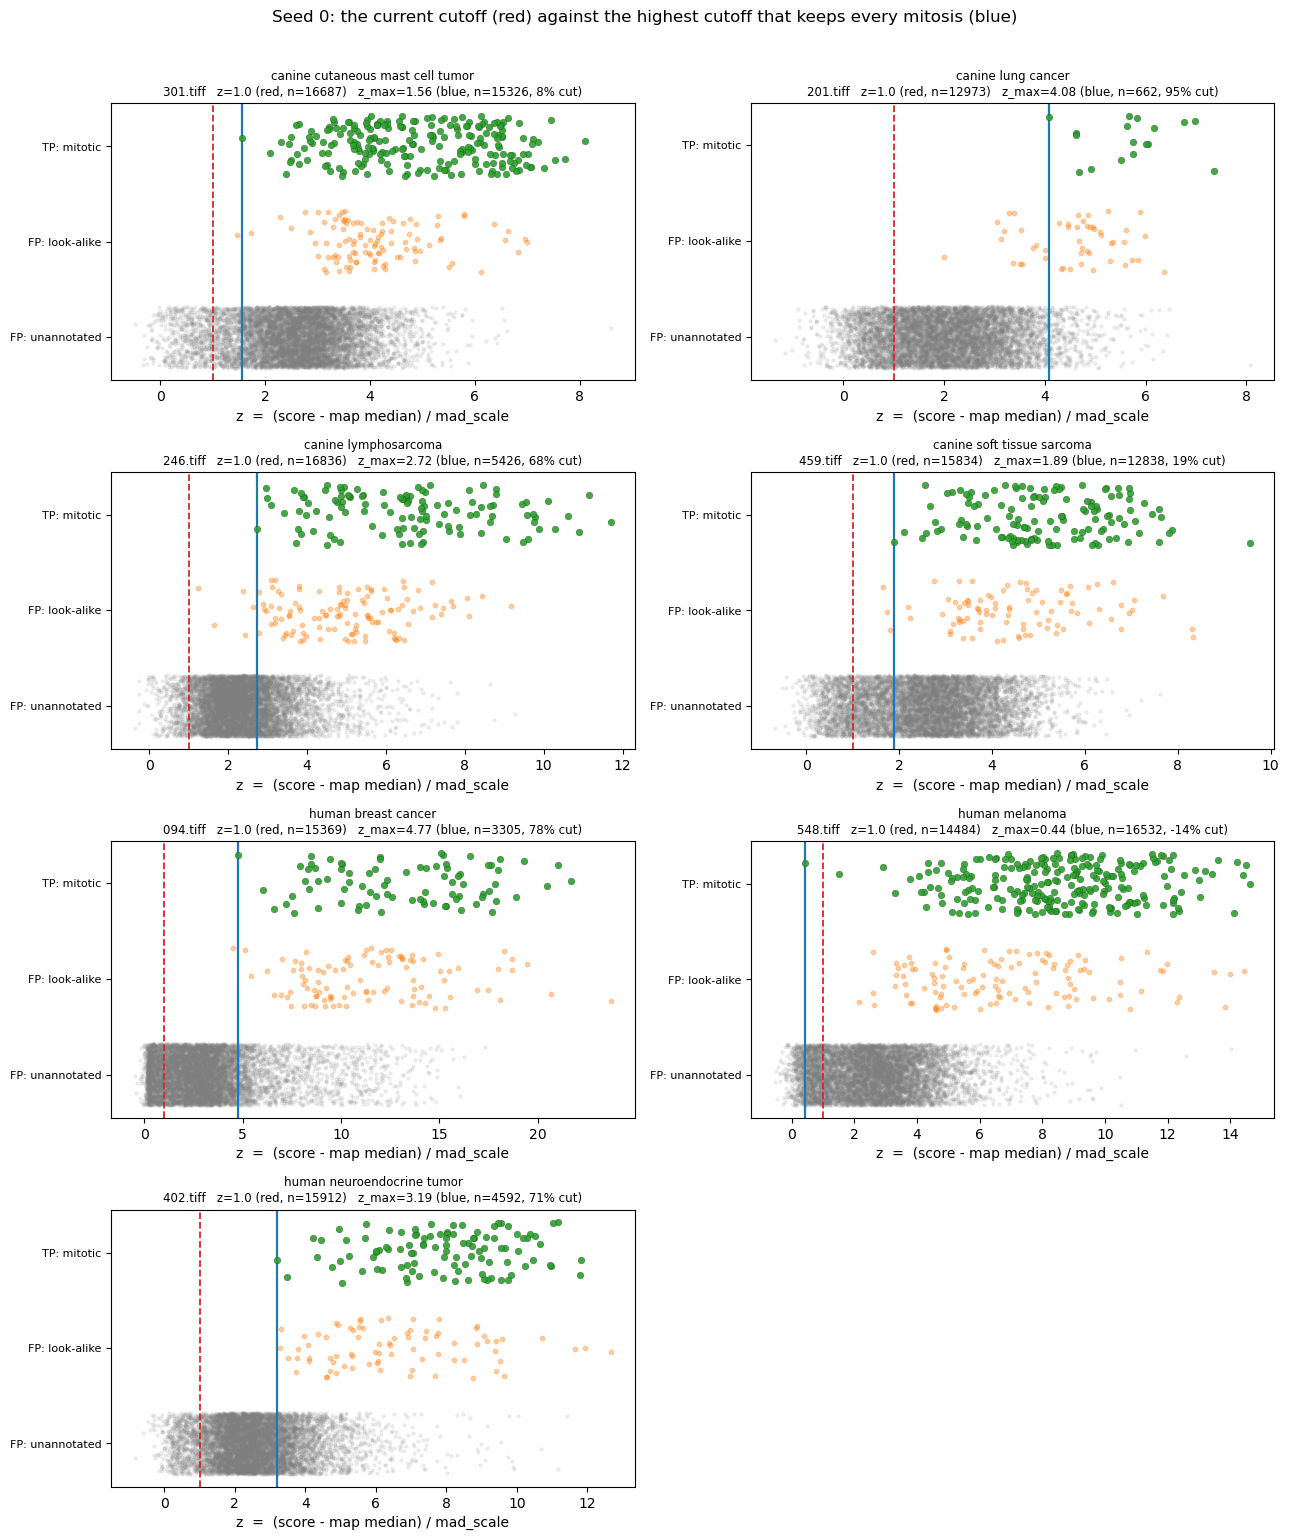

In [20]:
domains_by_file = domain_images.set_index('file_name')['tumor_type'].to_dict()
files = list(domain_images.sort_values('tumor_type')['file_name'])
n, ncols = len(files), 2
nrows = -(-n // ncols)
JITTER = 0.32
rng = np.random.default_rng(RNG_SEED)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, fn in zip(axes, files):
    det_out = pools[fn]
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            sub = sub.iloc[rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)]
        y = BUCKET_LANE[bucket] + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['z'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])
    zm = float(s0.loc[fn, 'z_max'])
    ax.axvline(CURRENT_Z, color='#d62728', linestyle='--', linewidth=1.3)
    ax.axvline(zm, color='#1f77b4', linestyle='-', linewidth=1.6)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('z  =  (score - map median) / mad_scale')
    ax.set_title(f"{domains_by_file[fn]}\n{fn}   z=1.0 (red, n={int(s0.loc[fn, 'n_at_current_z'])})"
                 f"   z_max={zm:.2f} (blue, n={int(s0.loc[fn, 'n_at_z_max'])}, "
                 f"{s0.loc[fn, 'pct_pool_cut']:.0f}% cut)", fontsize=8.5)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('Seed 0: the current cutoff (red) against the highest cutoff that keeps every '
             'mitosis (blue)', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## Closing summary of the **5.0 um** run, preserved verbatim

Per this repo's amend-rather-than-edit rule, the original closing summary is kept below
unchanged. **Every number in it is an output of the 5.0 um run**, not of this one -- the
per-domain `z_max` range, the 1.891 seed-0 minimum, the 1.308 deployable cutoff, the volume
percentages. The *arguments* are radius-independent and carry over unchanged: the prefix
identity, "read the cutoff not the recall at it", the three reasons the deployable number is an
upper bound, and what raising the cutoff does not buy.

**This run's own numbers are computed in the final section, after this one.** Read them there.

---

## Closing summary

**The question, answered.** Yes -- and the notebook that raised it already contained the exact
answer. `full_list_recall` on the `tm_score` axis is a prefix statistic (the pool is
score-descending, the cut is a prefix, and `evaluate.greedy_match` on a prefix is the first *N*
steps of the full pass), so the highest cutoff preserving every mitosis is exactly the lowest
`z` among the deep pool's TP-bucketed detections. That is `tp_z_min`, which lcc's cell 38
computes and never prints.

**Read the cutoff, not the recall at it.** Full recall *at* `z_max` is true by construction --
`z_max` is defined as the lowest TP score -- so it carries no information, at any coverage.
Check 2 is a software check that the harness agrees with the identity, not a detector result.
The measurement is the **value** of `z_max`: how far above each response map's median the
worst-ranked mitosis sits.

**Headroom (seed 0, oracle).** Per-domain `z_max` runs **1.89 (soft tissue sarcoma) to 4.77
(breast cancer)** against the current 1.0, cutting **26-96% of the pool (median 76.5%)**.
Full-list precision -- the only full-list quantity that moves, since recall is pinned at 1.0 --
goes from 0.10-1.14% to 0.84-2.99% (1.4x-24.8x). It is a large relative gain on a very small
number, and it is not available at inference time.

**Deployable (worst over 5 seeds).** The worst cell is **z = 1.308** (`459.tiff`, seed 3)
against seed 0's own per-domain minimum of 1.891 -- a single-seed reading overstates the
globally safe cutoff by **0.58 z**. Evaluated at the deployable cutoffs rather than interpolated: a **global** cutoff (`z = 1.308`, shippable at 1 dp as **`z = 1.3`**) is worth a median **10%** of the candidate pool (7-14% by domain) and leaves coverage at **0.84-0.98**; a **per-domain** cutoff, still worst-click within its domain, is worth a median **39%** (9-80%) at coverage 0.26-0.96. The seed-0 oracle figure -- what a single-seed reading would have claimed -- was 62%. `results/f1_seed_sweep.csv`, an independent
execution of the same configuration, agrees with the closed form on **all 210 (ROI, seed, z)
cells** and independently shows `459.tiff` -- and only `459.tiff` -- losing a mitosis at
`z = 1.5` on 2 of its 5 seeds.

**Three reasons the deployable number is an upper bound, not a recommendation:**

* **It has no margin and has not converged.** The running minimum over seeds fell twice in five
  draws, most recently at k=4. Flat over the last two is not convergence. The in-domain margin
  analysis (what dropping 1-2 mitoses buys) is done at seed 0 on the oracle `z_max` and is
  never repeated at the deployable level, so the two halves of this notebook do not meet.
* **The ROI half of D4's rule is untested.** One ROI per domain here, and D4's stated reason
  for "worst ROI, worst click, per domain" is precisely that the ROIs cluster by tumour type.
* **It is still label-derived**, and 2 of the 35 draws are duplicate clicks (33 distinct), so
  the sample is slightly thinner than `n_seeds = 5` suggests.

**What raising the cutoff does not buy.** Measured row-wise across every non-truncated arm-row:
`recall_at_budget` on `tm_score` moved in **zero** cells, and of the `read_*` cells **zero**
changed value while 15 became `NaN`. The pool is read from the top; raising the floor deletes
the bottom. The one arm where the product metric moved at all was `chromatin_od`'s top-K, and
**re-measuring it at the deployable cutoffs removes almost all of that**. The +0.118 recall@100
headline is at the oracle `z_max`. Measured at the global cutoff the per-domain median gain is
**+0.0000 in all seven domains at recall@100** (it moves at all in only 3 of 35 (domain, seed)
cells) and at most +0.0046 at recall@250; at the per-domain cutoffs the largest median gain is
**+0.0174**. Note this had to be *measured*, not extrapolated: the `chromatin_od` arm's
`recall_at_budget` is not monotone in the cutoff (it goes slightly negative in one domain at
z = 2.5), so a value bracketed between two equal grid points is not thereby pinned. All of it
is non-decision-grade under D5 regardless.

**Coverage, read correctly.** It cannot upgrade the recall at `z_max`. Where it does bite is
the deployable cutoff, and there it is unflattering: at `z ~ 1.31` coverage is still high
enough that a full-recall claim on an unseen ROI would be substantially geometric. That is
reported in the deployable table rather than left out.

**What would make this a decision.** The same measurement on the 14 ROIs of
`images/extra_valid/` at 5 seeds drawn *without* replacement, read as D4 requires, with a
margin taken deliberately rather than inherited from a single worst cell -- and the margin
table put to a pathologist as the question it actually is: how many mitoses per ROI may the
candidate list miss. `DECISIONS.md` D4's closing note names the machinery (conformal risk
control) that turns "this cutoff kept everything on these seven ROIs" into a coverage
guarantee on an unseen slide.

**Two corrections to `tm_threshold_axis_sweep_largest_cc.ipynb`**, from
`Research Logs/2026-09-04-largest-cc-z-headroom-audit.md`: its closing summary's claim that
every `read_95_delta` is smaller than that ROI's own seed-to-seed SD is false for `459.tiff`
(+1416 vs 1199) and `402.tiff` (-1547 vs 593) when the two lists are joined on `file_name`
rather than compared as sets -- the same error appears in finding 5 of the 2026-09-03 audit
log, which is where it came from. The verdict it supports survives on the three seed-0 endpoint
hits. And its `pool_sorted` uses pandas' default unstable sort where `compare._rank` and
`extract_peaks` both document mergesort; fixed here.

---

## Closing summary of **this** (7.5 um) run, and what the radius was worth

Three questions, each answered from this run's own CSVs against the 5.0 um run's:

1. **Does the smaller radius buy recall?** `z_max` is the highest cutoff that keeps every
   mitosis the search finds at all. If shrinking the radius were un-merging genuine neighbouring
   mitoses, the 5.0 um run would find TPs the 7.5 um run misses, and `deep_recall` would part.
2. **What does it cost?** Candidate volume at the reference operating point, per domain.
3. **Does the deliverable move?** The deployable cutoff -- worst click, per domain, and global
   -- is what this notebook exists to produce.

The comparison is paired per `(file_name, seed_index)`; the two runs share the seed draw
exactly (`np.random.default_rng([seed_index, image_id])` is radius-independent), which the
`seed_ann_id` check below confirms rather than assumes.

In [21]:
s50 = pd.read_csv('results/tm_ccoeff_high_z_seed_table.csv')
k = ['file_name', 'seed_index']
j = (seed_df.set_index(k).join(s50.set_index(k), rsuffix='_r50', how='inner')
     .reset_index().sort_values(['tumor_type', 'seed_index']))
assert len(j) == len(seed_df) == 35, f'seed tables do not pair 1:1 ({len(j)} rows)'
assert (j['seed_ann_id'] == j['seed_ann_id_r50']).all(), \
    'the two runs drew different seeds -- the comparison is not paired'
assert (j['base_size'] == j['base_size_r50']).all(), 'base_size moved with the radius'
print(f'{len(j)} (domain, seed) cells paired; identical seed click and template size in all.\n')

# ---- 1. recall -----------------------------------------------------------------------
print('1. DOES THE SMALLER RADIUS BUY RECALL?')
print(f"   deep_recall == 1.0  at 7.5 um: {int((j['deep_recall'] == 1.0).sum())}/{len(j)}"
      f"   at 5.0 um: {int((j['deep_recall_r50'] == 1.0).sum())}/{len(j)}")
_dr = (j['deep_recall_r50'] - j['deep_recall'])
print(f"   paired deep_recall difference (r5.0 - r7.5): min {_dr.min():+.4f}, "
      f"max {_dr.max():+.4f}, nonzero in {int((_dr != 0).sum())}/{len(j)} cells")
print('   -> the deep pool finds the same mitoses at both radii.' if (_dr == 0).all()
      else '   -> the radii differ on which mitoses are found; read the nonzero cells.')

# ---- 2. cost -------------------------------------------------------------------------
print('\n2. WHAT DOES IT COST? (candidate volume, per (domain, seed))')
j['pct_extra_pool_at_r50'] = 100 * (j['n_pool_r50'] / j['n_pool'] - 1)
j['pct_extra_at_z1_at_r50'] = 100 * (j['n_at_current_z_r50'] / j['n_at_current_z'] - 1)
vol = (j.groupby('tumor_type')[['n_pool', 'n_pool_r50', 'pct_extra_pool_at_r50',
                                'n_at_current_z', 'n_at_current_z_r50',
                                'pct_extra_at_z1_at_r50']].median().round(1))
print(vol.to_string())
print(f"\n   Deep pool: 5.0 um carries a median {j['pct_extra_pool_at_r50'].median():.1f}% more "
      f"candidates ({j['pct_extra_pool_at_r50'].min():.1f}% to "
      f"{j['pct_extra_pool_at_r50'].max():.1f}% across the 35 cells).")
print(f"   At z = {CURRENT_Z}: a median {j['pct_extra_at_z1_at_r50'].median():.1f}% more "
      f"({j['pct_extra_at_z1_at_r50'].min():.1f}% to {j['pct_extra_at_z1_at_r50'].max():.1f}%).")
print('   F5 measured +23.5% (r5.9) / +37.3% (r5.0) on its OWN 14-ROI untightened pool; the')
print('   number above is the same quantity re-measured on this pool, not transplanted.')

# ---- 3. the deliverable ---------------------------------------------------------------
print('\n3. DOES THE DELIVERABLE MOVE? (z_max, and the cutoffs built from it)')
# FLOORED to 4 dp, not rounded, to match cell 33's `z_max_min`. A displayed value above the
# measured minimum is a cutoff that drops a mitosis, so the two tables must not disagree even
# in the last digit -- rounding here printed 1.3079 where cell 33 printed 1.3078.
dom = pd.DataFrame({'z_max_r75': np.floor(j.groupby('tumor_type')['z_max'].min() * 1e4) / 1e4,
                    'z_max_r50': np.floor(j.groupby('tumor_type')['z_max_r50'].min() * 1e4) / 1e4})
dom['delta'] = (dom['z_max_r75'] - dom['z_max_r50']).round(4)
print(dom.to_string())
g75, g50 = float(j['z_max'].min()), float(j['z_max_r50'].min())
w75 = j.loc[j['z_max'].idxmin()]
print(f"\n   Global deployable cutoff (worst of all {len(j)} cells):")
print(f"     7.5 um -> z = {g75:.3f}  ({w75['file_name']}, {w75['tumor_type']}, "
      f"seed {int(w75['seed_index'])}), shippable at 1 dp as z = {np.floor(g75 * 10) / 10:.1f}")
print(f"     5.0 um -> z = {g50:.3f}, shippable as z = {np.floor(g50 * 10) / 10:.1f}")
print(f"     difference: {g75 - g50:+.3f} z")

dep = deploy_eval[deploy_eval['axis'] == 'tm_score'].drop_duplicates(['file_name', 'seed_index', 'cutoff_rule'])
piv = dep.pivot_table(index=['tumor_type', 'file_name', 'seed_index'],
                      columns='cutoff_rule', values='n_detections')
piv['cut_global_pct'] = (100 * (1 - piv['global'] / piv['current'])).round(1)
piv['cut_domain_pct'] = (100 * (1 - piv['domain'] / piv['current'])).round(1)
print(f"\n   At 7.5 um the global cutoff is worth a median "
      f"{piv['cut_global_pct'].median():.0f}% of the pool and the per-domain cutoff "
      f"{piv['cut_domain_pct'].median():.0f}%.")
# Stated the way cell 32's re-scoped guard states it: a cutoff is at fault only if it drops a
# mitosis ITS OWN pool found. Counting `full_list_recall < 1.0` here would re-import the
# pool-level miss as if the cutoff had caused it.
_sdz = seed_df.set_index(['file_name', 'seed_index'])
_tpd = (_sdz['deep_recall'] * _sdz['n_gt_mitotic']).round().astype(int)
_dd = deploy_eval[deploy_eval['cutoff_rule'] != 'current'].copy()
_dd['n_tp'] = (_dd['full_list_recall'] * _dd['n_gt_mitotic']).round().astype(int)
_dd['n_tp_deep'] = [_tpd[(f, si)] for f, si in zip(_dd['file_name'], _dd['seed_index'])]
print(f"   Mitoses dropped BY a deployable cutoff (pool-level misses excluded): "
      f"{int((_dd['n_tp'] < _dd['n_tp_deep']).sum())} rows -- the cutoff rule is sound at 7.5 um.")
print(f"   Mitoses the deep pool never found at 7.5 um: {int((_tpd.reindex(seed_df.set_index(['file_name','seed_index']).index) < seed_df.set_index(['file_name','seed_index'])['n_gt_mitotic']).sum())} cells affected -- that is the radius, reported in (1)." )
j.to_csv('results/tm_ccoeff_high_z_r75_vs_r50_seed_paired.csv', index=False)
print('\nwrote results/tm_ccoeff_high_z_r75_vs_r50_seed_paired.csv')

# ---- 4. the mechanism behind (3): peak substitution, not annotation loss -----------------
print('\n4. WHY z_max COLLAPSES EVEN WHERE RECALL HOLDS')
ta = pd.read_csv('results/tm_ccoeff_high_z_tp_z_values.csv')            # 5.0 um
tb = pd.read_csv('results/tm_ccoeff_high_z_r75_tp_z_values.csv')        # 7.5 um
ki = ['file_name', 'seed_index', 'matched_ann_id']
JJ = (ta.set_index(ki)[['z', 'score']]
      .join(tb.set_index(ki)[['z', 'score']], lsuffix='_r50', rsuffix='_r75', how='inner'))
JJ['dz'] = JJ['z_r75'] - JJ['z_r50']
wk, st = int((JJ['dz'] < -0.01).sum()), int((JJ['dz'] > 0.01).sum())
print(f'   Of {len(JJ)} annotations claimed by BOTH runs, the claiming peak is weaker at 7.5 um')
print(f'   in {wk}, stronger in {st}, unchanged in {int((JJ["dz"].abs() <= 0.01).sum())}.')
print('   The move is one-directional: a wider radius lets a neighbouring higher-scoring peak')
print('   suppress the strong on-centre peak, and the TP claim falls to a weaker survivor.')
print('   These are the SAME annotations, not different ones -- so it is invisible to recall')
print('   and fully visible to z_max, which reads the worst-ranked TP.\n')
print(JJ[JJ['dz'] < -0.5].sort_values('dz').round(3).to_string())
JJ.reset_index().to_csv('results/tm_ccoeff_high_z_r75_vs_r50_tp_substitution.csv', index=False)
print('\nwrote results/tm_ccoeff_high_z_r75_vs_r50_tp_substitution.csv')

35 (domain, seed) cells paired; identical seed click and template size in all.

1. DOES THE SMALLER RADIUS BUY RECALL?
   deep_recall == 1.0  at 7.5 um: 31/35   at 5.0 um: 35/35
   paired deep_recall difference (r5.0 - r7.5): min +0.0000, max +0.0174, nonzero in 4/35 cells
   -> the radii differ on which mitoses are found; read the nonzero cells.

2. WHAT DOES IT COST? (candidate volume, per (domain, seed))
                                   n_pool  n_pool_r50  pct_extra_pool_at_r50  n_at_current_z  n_at_current_z_r50  pct_extra_at_z1_at_r50
tumor_type                                                                                                                              
canine cutaneous mast cell tumor  18528.0     32225.0                   73.9         17529.0             29010.0                    64.5
canine lung cancer                15848.0     22631.0                   42.8         12973.0             16529.0                    27.4
canine lymphosarcoma              17784.0